# <div align="center"><b> Detección del picudo rojo mediante YoloV11 </b></div>

<div align="right">

<!-- [![Binder](http://mybinder.org/badge.svg)](https://mybinder.org/) -->
[![nbviewer](https://img.shields.io/badge/render-nbviewer-orange?logo=Jupyter)](https://nbviewer.org)
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://githubtocolab.com)

</div>

* * *

<style>
/* Limitar la altura de las celdas de salida en html */
.jp-OutputArea.jp-Cell-outputArea {
    max-height: 500px;
}
</style>

🛻 <em><font color='MediumSeaGreen'>  Instalaciones: </font></em> 🛻

Este notebook utiliza [Poetry](https://python-poetry.org/) para la gestión de dependencias.
Primero instala Poetry siguiendo las instrucciones de su [documentación oficial](https://python-poetry.org/docs/#installation).
Luego ejecuta el siguiente comando para instalar las dependencias necesarias y activar el entorno virtual:

- Bash:
```bash
poetry install
eval $(poetry env activate)
```

- PowerShell:
```powershell
poetry install
Invoke-Expression (poetry env activate)
```

<!-- Descargar archivos adicionales:
!gdown https://drive.google.com/drive/folders/1UBZ8PEbtmiWMGkULu7GAt3VhUpeTy9l7?usp=sharing --folder -->

In [1]:
# Chequear versión de CUDA
!nvcc --version

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2024 NVIDIA Corporation
Built on Wed_Oct_30_01:18:48_Pacific_Daylight_Time_2024
Cuda compilation tools, release 12.6, V12.6.85
Build cuda_12.6.r12.6/compiler.35059454_0


In [2]:
# Chequear más datos sobre la GPU
!nvidia-smi

Sun Sep 14 12:45:20 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 566.36                 Driver Version: 566.36         CUDA Version: 12.7     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4080 ...  WDDM  |   00000000:01:00.0 Off |                  N/A |
|  0%   32C    P8              4W /  320W |      15MiB /  16376MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

✋ <em><font color='DodgerBlue'>Importaciones:</font></em> ✋

In [3]:
# Recarga automática de módulos en Jupyter Notebook
%reload_ext autoreload
%autoreload 2

import sys, json, requests, os, shutil, yaml, random
from pathlib import Path
from pprint import pprint

from loguru import logger as LOGGER
from modulo_ia.config import config as CONFIG
from modulo_apps.database_comunication.mongodb_client import mongodb as MONGODB

os.environ["ALBUMENTATIONS_DISABLE"] = "1" # Deshabilita Albumentations por defecto.
import ultralytics
from ultralytics import YOLO, settings
from ultralytics.data.utils import visualize_image_annotations
import torch

import mlflow
import cv2
import PIL
from PIL import Image
import pandas as pd

import modulo_ia.dataset as DatasetProcessor
import modulo_ia.features as FeaturesProcessor
import modulo_ia.utils.gpu as GpuUtils
import modulo_ia.utils.yolo_utils as YoloUtils
from modulo_ia.modeling.predict import DetectionModelPredictor
from modulo_ia.utils.types import DatasetFormat

import modulo_apps.labeling.procesador_anotaciones_coco_dataset as CocoDatasetUtils
import modulo_apps.s3_comunication.procesador_s3 as ProcesadorS3
import modulo_apps.labeling.visualizador_coco_dataset as VisualizadorCocoDataset
import modulo_apps.labeling.procesador_anotaciones_mongodb as ProcesadorAnotacionesMongoDB
import modulo_apps.labeling.procesador_geojson_kml as ProcesadorGeoJSONKML
from modulo_apps.utils.types import ImageMetadata

2025-09-14 12:45:21.063 | INFO     | modulo_apps.config:<module>:18 - Directorio de configuración raíz: E:\Documentos\Git Repositories\uba-ceia-proy-final\ceia-proyecto-final\modulo-apps
2025-09-14 12:45:21.065 | INFO     | modulo_apps.config:<module>:22 - Variables de entorno cargadas desde .env.dev.


2025-09-14 12:45:21.076 | INFO     | modulo_ia.config:<module>:19 - Directorio de configuración raíz: E:\Documentos\Git Repositories\uba-ceia-proy-final\ceia-proyecto-final\modulo-IA
2025-09-14 12:45:21.079 | INFO     | modulo_ia.config:<module>:23 - Variables de entorno cargadas desde .env.dev.


e:\Documentos\Git Repositories\uba-ceia-proy-final\ceia-proyecto-final\modulo-IA\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2025-09-14 12:45:26.044 | DEBUG    | modulo_ia.modeling.predict:<module>:20 - Ambiente actual: dev


🔧 <em><font color='tomato'>Configuraciones:</font></em> 🔧


In [4]:
# CONFIGURACIONES GENERALES
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"  # Establece el dispositivo.
LOGGER.remove()
LOGGER.add(sys.stderr, level="INFO")
PIL.Image.MAX_IMAGE_PIXELS = None  # Evita errores con imágenes muy grandes

# COMPORTAMIENTO DEL NOTEBOOK
SHOULD_PROCESS_DATASET = False  # Descarga el dataset completo
SHOULD_TRAIN = True  # Entrenamiento
SHOULD_SEARCH_HYPERPARAMETERS = False  # Búsqueda de hiperparámetros

# CARPETAS
RAW_DATA_FOLDER = CONFIG.folders.raw_data_folder
EXTERNAL_DATA_FOLDER = CONFIG.folders.external_data_folder
INTERIM_DATA_FOLDER = CONFIG.folders.interim_data_folder
PROCESSED_DATA_FOLDER = CONFIG.folders.processed_data_folder
DATA_FOLDER = CONFIG.folders.data_folder
DOWNLOAD_COCO_ANNOTATIONS_FOLDER = Path("downloads") / "coco_annotations"  # Carpeta para descargar anotaciones COCO
DOWNLOAD_PREDICTION_FOLDER = Path("downloads") / "predictions"  # Carpeta para descargar parches de prueba
MODEL_FOLDER = CONFIG.folders.models_folder

# CONFIGURACIONES DE ENTRENAMIENTO
BATCH_SIZE = 16  # 16 -> Yolo11x | # 64 -> Yolo11n
N_EPOCHS = 300  # Número de épocas
VERBOSE = True  # Muestra época a época la evolución
IMG_SIZE = 640  # Tamaño de la imagen
RANDOM_SEED = CONFIG.seed  # Semilla para la aleatoriedad
CROP_THRESHOLD = 0.4  # Umbral de recorte para el dataset
BACKGROUND_PERCENTAGE = 0.1  # Porcentaje de fondo en el dataset balanceado
FREEZE_LAYERS = 10  # Número de capas a congelar
EARLY_STOPPING = 10  # Paciencia para el early stopping

# DATA AUGMENTATIONS
# Opciones: train_no_aumentations.yaml | train_custom1_aumentations.yaml | train_custom2_aumentations.yaml | train_custom3_aumentations.yaml
AUMENTATIONS_CONFIG_FILE_PATH = Path("train_no_aumentations.yaml")
CUSTOM_TRANSFORMS = [str(AUMENTATIONS_CONFIG_FILE_PATH).replace(".yaml", "")]

# TAREA
TASK_NAME = "rpw_detection"
CLASS_NAMES = {
    0: "palmera-sana",
    1: "palmera-infectada",
    2: "palmera-muerta",
}
COLOR_MAP = {
    "palmera-sana": (0, 255, 0),  # Verde
    "palmera-infectada": (255, 255, 0),  # Amarillo
    "palmera-muerta": (255, 0, 0),  # Rojo
}
CATEGORIES = [{"id": id, "name": name, "supercategory": ""} for id, name in CLASS_NAMES.items()]

# MODELO
MODEL_NAME = "yolo11x"
# Opciones: f"{MODEL_NAME}.pt" | Ruta al checkpoint personalizado
MODEL_CHECKPOINT = (
    MODEL_FOLDER / "coco_palm_dataset_v1.0_palm_detection_yolo11x_640_b7218a073a3942339689b2e7f4e0b543.pt"
)

# DATOS DEL DATASET
DATASET_NAME = CONFIG.names.palm_dataset_name
DATASET_VERSION = CONFIG.versions.v11
DATASET_IDENTIFIER = f"{DATASET_NAME}_{DATASET_VERSION}"
DATASET_FINAL_FORMAT = CONFIG.datasets_processed_format.yolo  # Formato final del dataset procesado

# RUTAS Y NOMBRES
DATASET_RAW_NAME = DATASET_IDENTIFIER
DATASET_RAW_PATH = RAW_DATA_FOLDER / DATASET_RAW_NAME
DATASET_INTERIM_NAME = DATASET_IDENTIFIER
DATASET_INTERIM_PATH = INTERIM_DATA_FOLDER / DATASET_INTERIM_NAME
DATASET_INTERIM_STEP_PATH = INTERIM_DATA_FOLDER / f"{DATASET_INTERIM_NAME}_step"
DATASET_INTERIM_STEP_NAME = f"{DATASET_INTERIM_NAME}_step"
DATASET_PROCESSED_NAME = f"{DATASET_IDENTIFIER}_{TASK_NAME}_{DATASET_FINAL_FORMAT}"
DATASET_PROCESSED_PATH = PROCESSED_DATA_FOLDER / DATASET_PROCESSED_NAME
EXPERIMENT_NAME = f"{DATASET_IDENTIFIER}_{TASK_NAME}_{MODEL_NAME.replace('/', '_')}_{IMG_SIZE}"
EXPERIMENT_NAME_STAGE = f"{EXPERIMENT_NAME}_stage_training"
EXPERIMENT_NAME_FULL_TRAINING = f"{EXPERIMENT_NAME}_full_training"
EXPERIMENT_NAME_TRANSFER_LEARNING = f"{EXPERIMENT_NAME}_transfer_learning"

# RESULTADOS
MODELS_PERFORMANCE_RESULTS = []

# MLFLOW
MLFLOW_URL = CONFIG.mlflow.tracking_uri
os.environ["MLFLOW_TRACKING_URI"] = MLFLOW_URL  # Configura la URI de seguimiento de MLflow.
os.environ["MLFLOW_TAGS"] = '{"model_family": "rpw_detection"}'  # Configura las etiquetas del experimento de MLflow.
settings.update({"mlflow": True})  # Habilita el uso de MLflow en ultralytics

# COMPROBACIONES
ultralytics.checks()  # Verifica la instalación de ultralytics
LOGGER.info(f"Dispositivo actual: {DEVICE}")

Ultralytics 8.3.161  Python-3.13.3 torch-2.7.1+cu128 CUDA:0 (NVIDIA GeForce RTX 4080 SUPER, 16376MiB)
Setup complete  (20 CPUs, 127.9 GB RAM, 892.9/1862.9 GB disk)


2025-09-14 12:45:26.274 | INFO     | __main__:<module>:90 - Dispositivo actual: cuda


<div align="center">✨Datos del proyecto:✨</div>

<p></p>

<div align="center">

| **Subtitulo**   | Detección de rpw - YoloV11                                                                                                        |
| --------------- | -------------------------------------------------------------------------------------------------------------------------------------- |
| **Descrpción**  | <small>Notebook de detección del picudo rojo utilizando YoloV11</small>                                                                    |

</div>

## Chequeo de conexiones

In [5]:
# Chequeo de conexión a MLflow
LOGGER.info(f"Conectando a MLflow en {MLFLOW_URL}...")
try:
    response = requests.get(MLFLOW_URL)
    response.raise_for_status()  # Verifica si la solicitud fue exitosa.
    LOGGER.success("Conexión a MLflow establecida correctamente.")
except Exception as e:
    LOGGER.error(f"Error al conectar con MLflow. Tienes levantado el servidor de MLflow?")
    raise SystemExit(f"Error al conectar con MLflow: {e}")

# Chequeo de conexión a MinIO
LOGGER.info("Chequeando conexión a MinIO...")
ProcesadorS3.test_connection()

# Chequeo de conexión a MongoDB
LOGGER.info("Chequeando conexión a MongoDB...")
ProcesadorAnotacionesMongoDB.test_connection()
LOGGER.success("Conexión a MongoDB verificada correctamente.")

2025-09-14 12:45:26.317 | INFO     | __main__:<module>:2 - Conectando a MLflow en http://localhost:5000...
2025-09-14 12:45:26.324 | SUCCESS  | __main__:<module>:6 - Conexión a MLflow establecida correctamente.
2025-09-14 12:45:26.324 | INFO     | __main__:<module>:12 - Chequeando conexión a MinIO...
2025-09-14 12:45:26.330 | SUCCESS  | modulo_apps.s3_comunication.procesador_s3:test_connection:39 - Conexión exitosa a S3 y acceso al bucket 'picudo-rojo-bucket' verificado.
2025-09-14 12:45:26.330 | INFO     | __main__:<module>:16 - Chequeando conexión a MongoDB...
2025-09-14 12:45:26.345 | SUCCESS  | modulo_apps.labeling.procesador_anotaciones_mongodb:test_connection:38 - Conexión a la base de datos MongoDB exitosa.
2025-09-14 12:45:26.346 | SUCCESS  | __main__:<module>:18 - Conexión a MongoDB verificada correctamente.


## Raw dataset

In [6]:
if DATASET_RAW_PATH.exists():
    LOGGER.info("Dataset ya descargado. Procesando dataset...")

    dataset_metrics = DatasetProcessor.get_dataset_metrics(
        dataset_path=DATASET_RAW_PATH, dataset_name=DATASET_RAW_NAME, dataset_format=DatasetProcessor.DatasetFormat.COCO
    )
    dataset_stats = DatasetProcessor.get_dataset_stats(
        dataset_path=DATASET_RAW_PATH, dataset_name=DATASET_RAW_NAME, dataset_format=DatasetProcessor.DatasetFormat.COCO
    )
    LOGGER.info(f"Metricas del dataset:\n {json.dumps(dataset_metrics, indent=2)}")
    LOGGER.info(f"Estadísticas del dataset:\n {json.dumps(dataset_stats, indent=2)}")
else:
    LOGGER.error(f"El dataset no fue encontrado en {DATASET_RAW_PATH}. Tienes que descargarlo previamente.")
    sys.exit(1)

2025-09-14 12:45:26.392 | INFO     | __main__:<module>:2 - Dataset ya descargado. Procesando dataset...


You are running the oldest supported major version of MongoDB. Please refer to https://deprecation.voxel51.com for deprecation notices. You can suppress this exception by setting your `database_validation` config parameter to `False`. See https://docs.voxel51.com/user_guide/config.html#configuring-a-mongodb-connection for more information
 100% |███████████████| 1288/1288 [5.5s elapsed, 0s remaining, 218.6 samples/s]      
 100% |███████████████| 1288/1288 [5.6s elapsed, 0s remaining, 187.9 samples/s]      


2025-09-14 12:45:41.530 | INFO     | __main__:<module>:10 - Metricas del dataset:
 {
  "total_images_count": 1288,
  "total_images_with_detections": 1288,
  "total_images_without_detections": 0,
  "class_count": {
    "palmera-sana": 8403,
    "palmera-exterminada": 191,
    "palmera-infectada": 170,
    "palmera-muerta": 280
  }
}
2025-09-14 12:45:41.530 | INFO     | __main__:<module>:11 - Estadísticas del dataset:
 {
  "samples_count": 1288,
  "samples_bytes": 2802954,
  "samples_size": "2.7MB",
  "media_bytes": 0,
  "media_size": "0.0B",
  "total_bytes": 2802954,
  "total_size": "2.7MB"
}


## Procesamiento del dataset

### Procesamiento de labels

Mostramos las clases originales:

In [7]:
with open(DATASET_RAW_PATH / "labels.json", "r") as f:
    labels_data = json.load(f)
LOGGER.info(f"Clases originales:\n {json.dumps(labels_data['categories'], indent=2)}")

2025-09-14 12:45:41.608 | INFO     | __main__:<module>:3 - Clases originales:
 [
  {
    "id": 0,
    "name": "palmera-sana",
    "supercategory": ""
  },
  {
    "id": 1,
    "name": "palmera-infectada",
    "supercategory": ""
  },
  {
    "id": 2,
    "name": "palmera-muerta",
    "supercategory": ""
  },
  {
    "id": 3,
    "name": "palmera-exterminada",
    "supercategory": ""
  }
]


In [8]:
CUSTOM_TRANSFORMS.append("delete_label: palmera-exterminada")  # Agrega la transformación de eliminación de etiqueta
if SHOULD_PROCESS_DATASET:
    LOGGER.debug("Copiando dataset...")
    # Copiamos el dataset a la carpeta de datos
    shutil.copytree(DATASET_RAW_PATH, DATASET_INTERIM_PATH, dirs_exist_ok=True)

    json_folder = DATASET_INTERIM_PATH
    coco_anotations = CocoDatasetUtils.load_annotations_from_path(json_folder / "labels.json")

    LOGGER.info("Eliminando etiqueta 'palmera-exterminada'...")    
    coco_anotations = CocoDatasetUtils.delete_label(coco_anotations, "palmera-exterminada")

    with open(json_folder / "labels.json", "w") as f:
        json.dump(coco_anotations, f, indent=4)
        LOGGER.info(f"Se copió el dataset y se guardó el archivo de etiquetas en {json_folder / 'labels.json'}")

    LOGGER.info(f"Nuevas categorías:\n {json.dumps(coco_anotations['categories'], indent=2)}")

### Convertir dataset a formato YOLO
<small><em>https://docs.ultralytics.com/reference/cfg/__init__/</em></small>

In [9]:
if SHOULD_PROCESS_DATASET:
    LOGGER.info("Convirtiendo el dataset a formato de modelo...")
    DatasetProcessor.convert_dataset_to_model_format(dataset_path=DATASET_INTERIM_PATH, output_dir=DATASET_INTERIM_STEP_PATH, clean=True)

Ejemplo con views splits:

```python
for split in splits:
    split_view = dataset_or_view.match_tags(split)
    split_view.export(
        export_dir=export_dir,
        dataset_type=fo.types.YOLOv5Dataset,
        label_field=label_field,
        split=split,
        classes=classes,
    )
```

### Recortar el dataset en imágenes pequeñas

In [10]:
CUSTOM_TRANSFORMS.append(f"crop: {CROP_THRESHOLD}")  # Agrega la transformación de recorte
if SHOULD_PROCESS_DATASET:
    LOGGER.info("Cortando el dataset para entrenamiento...")
    
    FeaturesProcessor.crop_dataset(dataset_path=DATASET_INTERIM_STEP_PATH, image_size=IMG_SIZE, threshold=CROP_THRESHOLD)

    dataset_metrics = DatasetProcessor.get_dataset_metrics(
        dataset_path=DATASET_INTERIM_STEP_PATH,
        dataset_name=DATASET_INTERIM_STEP_NAME,
        dataset_format=DatasetFormat.YOLO,
    )
    LOGGER.info(f"Metricas del dataset:\n {json.dumps(dataset_metrics, indent=2)}")

### Balancear el dataset

In [11]:
CUSTOM_TRANSFORMS.append(f"balance: {BACKGROUND_PERCENTAGE}")  # Agrega la transformación de balanceo
if SHOULD_PROCESS_DATASET:
    LOGGER.info("Balanceando el dataset...")
    FeaturesProcessor.balance_dataset_v1(
        dataset_path=DATASET_INTERIM_STEP_PATH,
        output_path=DATASET_INTERIM_STEP_PATH,
        all_classes=True,
        background_precentage=BACKGROUND_PERCENTAGE,
        export_categories=CATEGORIES,
    )

    dataset_metrics = DatasetProcessor.get_dataset_metrics(
        dataset_path=DATASET_INTERIM_STEP_PATH,
        dataset_name=DATASET_INTERIM_STEP_NAME,
        dataset_format=DatasetFormat.YOLO,
    )
    LOGGER.info(f"Metricas del dataset:\n {json.dumps(dataset_metrics, indent=2)}")

### Split del dataset

In [12]:
CUSTOM_TRANSFORMS.append("split: 0.8, 0.1, 0.1")  # Agrega la transformación de split
if SHOULD_PROCESS_DATASET:
    LOGGER.info("Split del dataset...")
    DatasetProcessor.split_dataset(dataset_path=DATASET_INTERIM_STEP_PATH, output_dir=DATASET_PROCESSED_PATH, clean=True, ratios=(0.8, 0.1, 0.1))

### Validaciones del dataset

#### Existencia del archivo dataset.yaml

In [13]:
dataset_yaml_path = DATASET_PROCESSED_PATH / "dataset.yaml"
if not dataset_yaml_path.exists():
    raise FileNotFoundError(f"El archivo {dataset_yaml_path} no existe. Asegúrate de que el dataset se haya procesado correctamente.")
LOGGER.success(f"Archivo dataset.yaml encontrado en {dataset_yaml_path}")

2025-09-14 12:45:41.910 | SUCCESS  | __main__:<module>:4 - Archivo dataset.yaml encontrado en E:\Documentos\Git Repositories\uba-ceia-proy-final\ceia-proyecto-final\modulo-IA\data\processed\coco_palm_dataset_v1.1_rpw_detection_yolo\dataset.yaml


#### Congruencia de las clases

In [14]:
with open(dataset_yaml_path, "r") as f:
    dataset_yaml = yaml.safe_load(f)
    LOGGER.debug(f"Dataset YAML cargado: {dataset_yaml}")

DATASET_YAML_CLASS_NAMES = dataset_yaml["names"]
if set(DATASET_YAML_CLASS_NAMES.values()) != set(CLASS_NAMES.values()):
    raise ValueError(
        f"Las clases del dataset YAML {DATASET_YAML_CLASS_NAMES} no coinciden con las esperadas {CLASS_NAMES.values()}."
    )

LOGGER.success("Validaciones de clases realizadas correctamente.")

2025-09-14 12:45:41.964 | SUCCESS  | __main__:<module>:11 - Validaciones de clases realizadas correctamente.


### Metricas del dataset procesado

In [15]:
dataset_metrics = DatasetProcessor.get_dataset_metrics(
    dataset_path=DATASET_PROCESSED_PATH,
    dataset_name=DATASET_PROCESSED_NAME,
    dataset_format=DatasetProcessor.DatasetFormat.YOLO,
)
dataset_metrics_json = json.dumps(dataset_metrics, indent=2)
LOGGER.info(f"Metricas del dataset:\n {dataset_metrics_json}")

 100% |█████████████████| 519/519 [497.7ms elapsed, 0s remaining, 1.0K samples/s]      
 100% |███████████████████| 65/65 [61.1ms elapsed, 0s remaining, 1.1K samples/s]     
 100% |███████████████████| 65/65 [55.6ms elapsed, 0s remaining, 1.2K samples/s]      


2025-09-14 12:45:42.690 | WARNING  | modulo_ia.dataset:get_dataset_metrics:442 - Advertencia: no se pudo agregar el split "full" al dataset. Error: Dataset YAML 'E:\Documentos\Git Repositories\uba-ceia-proy-final\ceia-proyecto-final\modulo-IA\data\processed\coco_palm_dataset_v1.1_rpw_detection_yolo\dataset.yaml' does not contain split 'full'
2025-09-14 12:45:42.707 | INFO     | __main__:<module>:7 - Metricas del dataset:
 {
  "train_count": 519,
  "train_images_with_detections": 468,
  "train_images_without_detections": 51,
  "train_class_count": {
    "palmera-infectada": 289,
    "palmera-sana": 411,
    "palmera-muerta": 262
  },
  "val_count": 65,
  "val_images_with_detections": 63,
  "val_images_without_detections": 2,
  "val_class_count": {
    "palmera-sana": 52,
    "palmera-infectada": 38,
    "palmera-muerta": 33
  },
  "test_count": 65,
  "test_images_with_detections": 59,
  "test_images_without_detections": 6,
  "test_class_count": {
    "palmera-muerta": 37,
    "palmera-s

### Visualización

#### Observamos el dataset

> 📝 <em><font color='Gray'>Nota:</font></em> Si hay problema de versiones con `FiftyOne`, borrar la base de datos del mismo que se encuentra en: `C:\Users\<usuario>\.fiftyone\`</em>

In [16]:
if SHOULD_PROCESS_DATASET:
    DatasetProcessor.copy_dataset_to_quality(DATASET_PROCESSED_PATH, DATASET_PROCESSED_NAME)

Accedemos a la visualización: <a>http://picudo-rojo-desarrollo.org:5151</a>

#### Observamos algunas imágenes

2025-09-14 12:45:42.798 | INFO     | __main__:<module>:14 - Archivo de texto seleccionado para visualización: E:\Documentos\Git Repositories\uba-ceia-proy-final\ceia-proyecto-final\modulo-IA\data\processed\coco_palm_dataset_v1.1_rpw_detection_yolo\labels\train\RGB_MVD_2024_J-29-C-2-P-4_patch_25_crop_37.txt


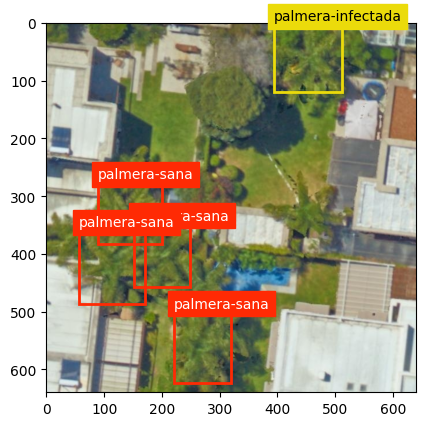

In [17]:
train_image_folder = DATASET_PROCESSED_PATH / "images" / "train"
train_annotations_folder = DATASET_PROCESSED_PATH / "labels" / "train"
# Select one random image from the train folder
if not train_image_folder.exists() or not train_annotations_folder.exists():
    raise FileNotFoundError(
        f"Las carpetas de entrenamiento no existen: {train_image_folder} o {train_annotations_folder}. Asegúrate de que el dataset se haya procesado correctamente."
    )
text_files = list(train_annotations_folder.glob("*.txt"))
if not text_files:
    raise FileNotFoundError(
        f"No se encontraron archivos de texto en {train_annotations_folder}. Asegúrate de que el dataset se haya procesado correctamente."
    )
text_path = random.choice(text_files)
LOGGER.info(f"Archivo de texto seleccionado para visualización: {text_path}")

image_path = train_image_folder / text_path.with_suffix(".jpg").name
if not image_path.exists():
    raise FileNotFoundError(
        f"La imagen {image_path} no existe. Asegúrate de que el dataset se haya procesado correctamente."
    )

category_map = {cat["id"]: cat["name"] for cat in CATEGORIES}

visualize_image_annotations(image_path, text_path, category_map)

#### Observamos el aumento de datos

train: Fast image access  (ping: 0.00.0 ms, read: 1338.4382.4 MB/s, size: 172.0 KB)


train: Scanning E:\Documentos\Git Repositories\uba-ceia-proy-final\ceia-proyecto-final\modulo-IA\data\processed\coco_palm_dataset_v1.1_rpw_detection_yolo\labels\train.cache... 519 images, 51 backgrounds, 0 corrupt: 100%|██████████| 519/519 [00:00<?, ?it/s]


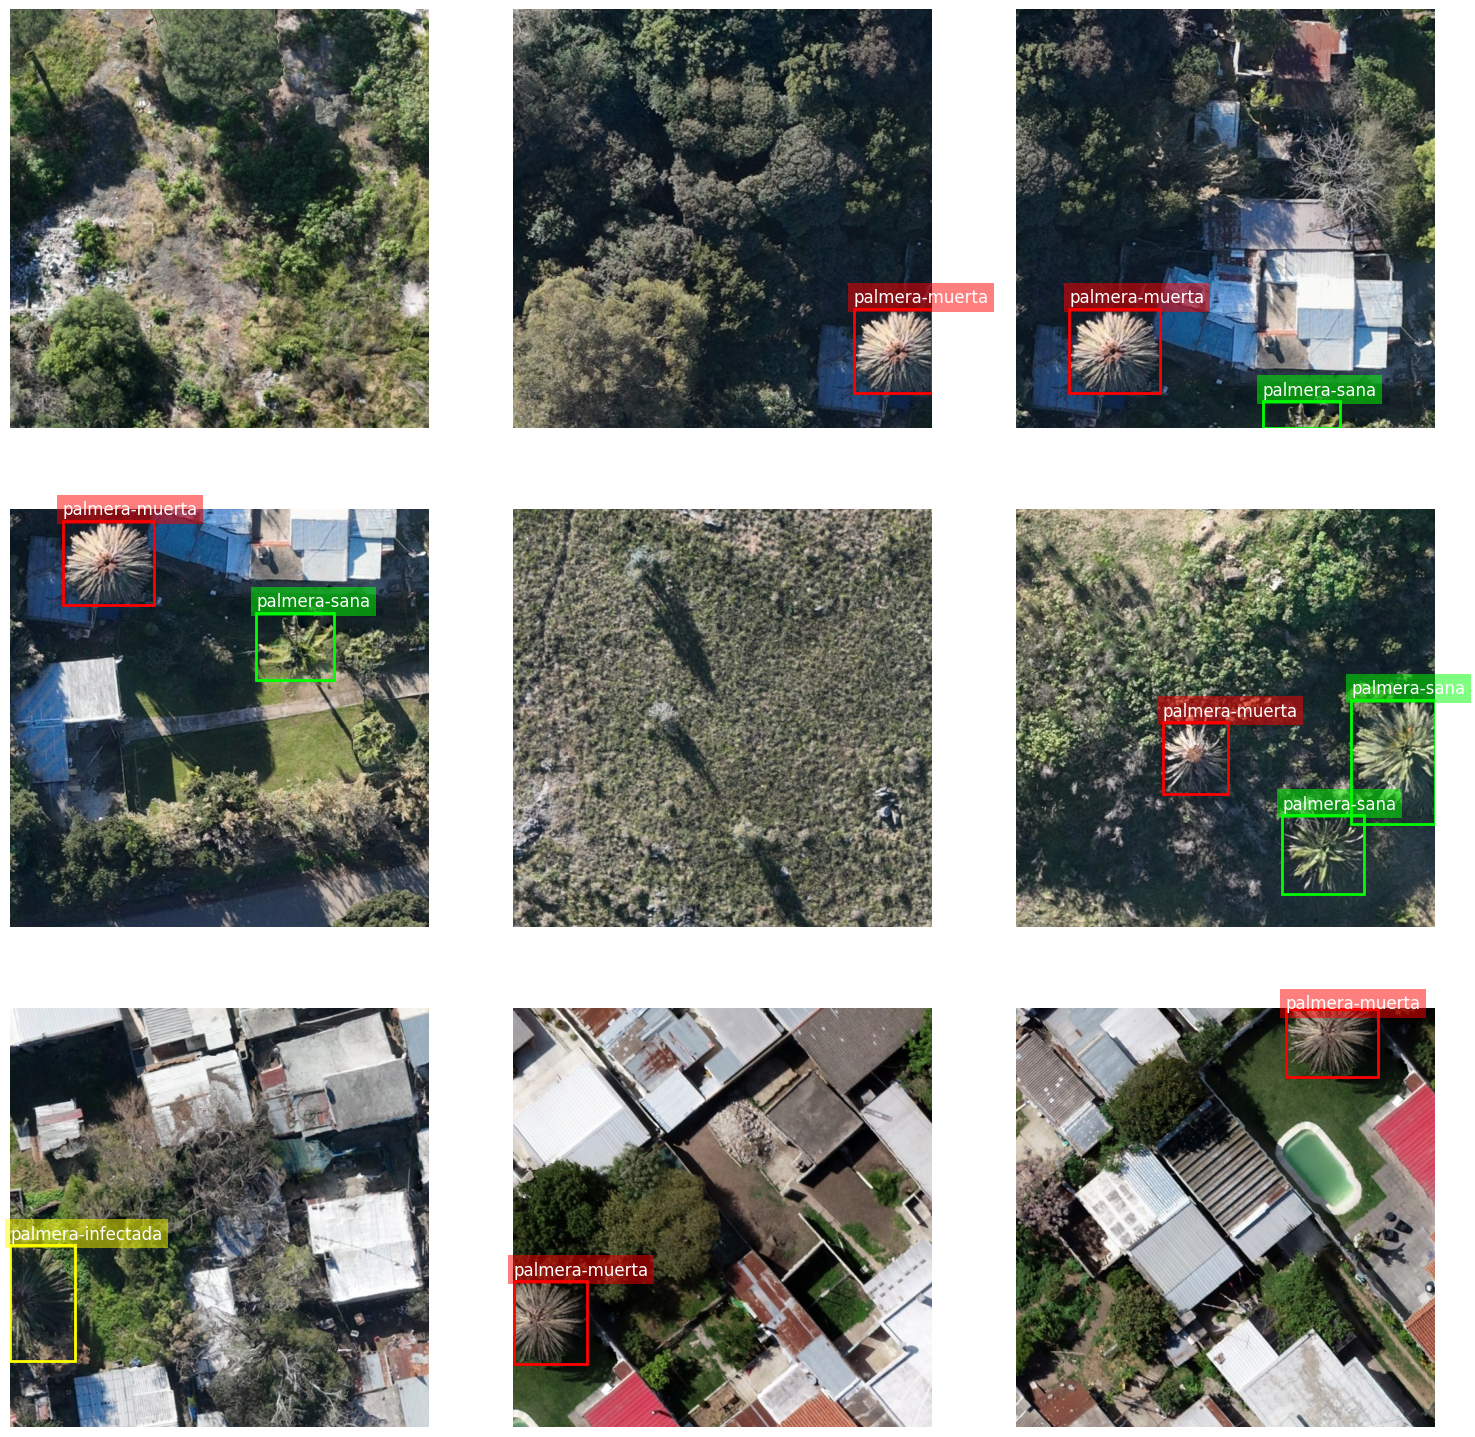

In [18]:
yolo_training_dataloader = YoloUtils.get_yolo_training_dataloader(
    cfg_path=AUMENTATIONS_CONFIG_FILE_PATH,
    cfg_data=DATASET_PROCESSED_PATH / "dataset.yaml",
    cfg_imgsz=IMG_SIZE,
    cfg_batch=9,
    dataset_path=DATASET_PROCESSED_PATH / "images" / "train",
    shuffle=False,
)
YoloUtils.plot_yolo_augmentations(yolo_training_dataloader, CLASS_NAMES, color_map=COLOR_MAP, max_batches=1)

## Entrenamientos de modelos

$\rightarrow$ Entrenamiento el modelo:
- <small>https://docs.ultralytics.com/yolov5/tutorials/tips_for_best_training_results/#advanced-optimization-techniques</small>
- <small>https://docs.ultralytics.com/guides/yolo-data-augmentation/#introduction</small>

$\rightarrow$ Configuraciones de entrenamiento:
- <small><em>https://docs.ultralytics.com/modes/train/#train-settings</em></small>

$\rightarrow$ Transfer Learning:
- <small>https://www.ultralytics.com/glossary/transfer-learning</small>
- <small>https://docs.ultralytics.com/yolov5/tutorials/transfer_learning_with_frozen_layers/#how-layer-freezing-works</small>
- <small>https://community.ultralytics.com/t/guidance-on-freezing-layers-for-yolov8x-seg-transfer-learning/189</small>

$\rightarrow$ Batch size:
> 📝 <em><font color='Gray'>Nota:</font></em> $\text{Max batch size} = \frac{\text{Available GPU memory (bytes)}}{4 \times (\text{Size of tensors} + \text{Trainable parameters})}$

$\rightarrow$ Hiperparámetros:
- <small><em>https://docs.ultralytics.com/guides/hyperparameter-tuning/</em></small>
- <small><em>https://docs.ultralytics.com/integrations/ray-tune/</em></small>

$\rightarrow$ Ejemplo search grid:
Ejemplo de uso de grid search para hiperparámetros:

```python
from ultralytics import YOLO
import itertools

param_grid = {
    'imgsz': [240, 256, 416],
    'batch': [16, 32, 64],
    'momentum': [0.937, 0.8],
    'optimizer': ['adam', 'adamW'],
}

# Generate combinations
param_combinations = list(itertools.product(*param_grid.values()))

best_map = 0
best_params = {}
for combination in param_combinations:
    params = dict(zip(param_grid.keys(), combination))
    model = YOLO('yolov8n.pt')
    results = model.train(data='coco128.yaml', epochs=50, **params)
    if results['val/mAP_0.5'] > best_map:
        best_map = results['val/mAP_0.5']
        best_params = params

print("Best mAP: {:.4f} with Parameters: {}".format(best_map, best_params))
```

### Datos del modelo base

Checkpoint:

In [19]:
print(f"Checkpoint del modelo base: {MODEL_CHECKPOINT}")
model = YOLO(MODEL_CHECKPOINT)

Checkpoint del modelo base: E:\Documentos\Git Repositories\uba-ceia-proy-final\ceia-proyecto-final\modulo-IA\models\coco_palm_dataset_v1.0_palm_detection_yolo11x_640_b7218a073a3942339689b2e7f4e0b543.pt


Resumen de arquitectura:

In [20]:
for name, param in model.named_parameters():
    print(name)

model.model.0.conv.weight
model.model.0.bn.weight
model.model.0.bn.bias
model.model.1.conv.weight
model.model.1.bn.weight
model.model.1.bn.bias
model.model.2.cv1.conv.weight
model.model.2.cv1.bn.weight
model.model.2.cv1.bn.bias
model.model.2.cv2.conv.weight
model.model.2.cv2.bn.weight
model.model.2.cv2.bn.bias
model.model.2.m.0.cv1.conv.weight
model.model.2.m.0.cv1.bn.weight
model.model.2.m.0.cv1.bn.bias
model.model.2.m.0.cv2.conv.weight
model.model.2.m.0.cv2.bn.weight
model.model.2.m.0.cv2.bn.bias
model.model.2.m.0.cv3.conv.weight
model.model.2.m.0.cv3.bn.weight
model.model.2.m.0.cv3.bn.bias
model.model.2.m.0.m.0.cv1.conv.weight
model.model.2.m.0.m.0.cv1.bn.weight
model.model.2.m.0.m.0.cv1.bn.bias
model.model.2.m.0.m.0.cv2.conv.weight
model.model.2.m.0.m.0.cv2.bn.weight
model.model.2.m.0.m.0.cv2.bn.bias
model.model.2.m.0.m.1.cv1.conv.weight
model.model.2.m.0.m.1.cv1.bn.weight
model.model.2.m.0.m.1.cv1.bn.bias
model.model.2.m.0.m.1.cv2.conv.weight
model.model.2.m.0.m.1.cv2.bn.weight
mo

Arquitectura del modelo base:

In [21]:
print(model)

YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 96, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(96, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(96, 192, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(192, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C3k2(
        (cv1): Conv(
          (conv): Conv2d(192, 192, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(192, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(384, 384, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(384, eps=0.001, momentum=0.03, affine=True, track_

### Entrenamiento del modelo - Full training

In [22]:
model = YOLO(MODEL_CHECKPOINT)

#### Busqueda de hiperparámetros

In [23]:
space_search = {
    "lr0": [0.01, 0.001, 0.0001],  # Learning rate
    "lrf": [0.1, 0.01],  # Learning rate final como una fracción de lr0
    "box": [7.5, 4.0, 0.5],  # Box loss gain
    "cls": [7.5, 4.0, 0.5],  # Class loss gain
    "dfl": [7.5, 4.0, 1.5, 0.5],  # DFL loss gain
}

In [24]:
if SHOULD_SEARCH_HYPERPARAMETERS:
    settings.update({"mlflow": False})
    model.tune(
        data=str(DATASET_PROCESSED_PATH / "dataset.yaml"),
        batch=BATCH_SIZE,
        project=f"{EXPERIMENT_NAME_FULL_TRAINING}_hyperparameter_search",
        iterations=300,
        epochs=100,
        space=space_search,
        optimizer="SGD",
        plots=False,
        save=False,
        val=False,
    )
    settings.update({"mlflow": True})

#### Entrenamiento

In [ ]:
if SHOULD_TRAIN:
    experiment = mlflow.set_experiment(EXPERIMENT_NAME_FULL_TRAINING)
    with mlflow.start_run(experiment_id=experiment.experiment_id):
        mlflow.log_param("dataset_name", DATASET_NAME)  # Registra el nombre del dataset
        mlflow.log_param("dataset_version", DATASET_VERSION)  # Registra la versión del dataset
        mlflow.log_param("dataset_format", DATASET_FINAL_FORMAT)  # Registra el formato del dataset
        mlflow.log_param("dataset_processed_name", DATASET_PROCESSED_NAME)  # Registra el nombre del dataset procesado
        mlflow.log_param("dataset_metrics", dataset_metrics_json)  # Registra las métricas del dataset como JSON
        mlflow.log_param(
            "transforms", ", ".join(CUSTOM_TRANSFORMS)
        )  # Registra las transformaciones aplicadas al dataset
        mlflow.log_param("model_name", MODEL_NAME)  # Registra el nombre del modelo
        mlflow.log_param("model_checkpoint", MODEL_CHECKPOINT)  # Registra el checkpoint del modelo
        mlflow.log_param("img_size", IMG_SIZE)  # Registra el tamaño de la imagen
        mlflow.log_param("crop_threshold", CROP_THRESHOLD)  # Registra el umbral de recorte
        mlflow.log_param(
            "background_percentage", BACKGROUND_PERCENTAGE
        )  # Registra el porcentaje de fondo en el dataset balanceado

        # ========================
        # 🔹 Entrenamiento total
        # ========================}
        mlflow.log_param("stage", "full_training")
        mlflow.log_param("freeze_layers", 0)
        full_training_history = model.train(
            cfg=str(AUMENTATIONS_CONFIG_FILE_PATH),  # Configuración de aumentaciones
            data=str(DATASET_PROCESSED_PATH / "dataset.yaml"),
            # epochs=N_EPOCHS,
            epochs=50,
            batch=BATCH_SIZE,
            device=0,  # Usa la GPU 0
            verbose=VERBOSE,  # Muestra época a época la evolución
            imgsz=IMG_SIZE,
            project=experiment.name,
            exist_ok=True,
            # save_period=10,
            patience=10,
            plots=True,
            # cache=True, # Cachea las imágenes en memoria para acelerar el entrenamiento
            # Parámetros de configuración del entrenamiento
            # optimizer="SGD", # Valores posibles: SGD, Adam, AdamW, NAdam, RAdam, RMSProp. Defecto=auto
            # cos_lr=True, # Usa decaimiento cosenoidal del learning rate
            # lr0=0.001, # Learning rate inicial. Default=0.01
            # lrf=0.01, # Tasa de aprendizaje final como una fracción de la tasa inicial = (lr0 * lrf). Valor alto=menos decaimiento. Default=0.01, 1% del lr0.
            # momentum=0.937, # Factor de momento para SGD o beta1 para optimizadores Adam
            # weight_decay=0.0005 # Peso de decaimiento (L2 regularization)
            # warmup_epochs=3.0, # Número de épocas para el calentamiento de la tasa de aprendizaje (aumenta gradualmente el lr hasta lr0). Defecto: 3.0
            # warmup_momentum=0.8, # Momentum inicial del calentamiento
            # warmup_bias_lr=0.1, # Tasa de aprendizaje para los parámetros de sesgo durante la fase de calentamiento (ayuda a estabilizar el entrenamiento al inicio)
            # dropout=0.0, # Tasa de dropout
        )

New https://pypi.org/project/ultralytics/8.3.199 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.161  Python-3.13.3 torch-2.7.1+cu128 CUDA:0 (NVIDIA GeForce RTX 4080 SUPER, 16376MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=None, batch=16, bgr=0.0, box=7.5, cache=False, cfg=train_no_aumentations.yaml, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=E:\Documentos\Git Repositories\uba-ceia-proy-final\ceia-proyecto-final\modulo-IA\data\processed\coco_palm_dataset_v1.1_rpw_detection_yolo\dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=300, erasing=0.0, exist_ok=True, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.0, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det

train: Scanning E:\Documentos\Git Repositories\uba-ceia-proy-final\ceia-proyecto-final\modulo-IA\data\processed\coco_palm_dataset_v1.1_rpw_detection_yolo\labels\train.cache... 519 images, 51 backgrounds, 0 corrupt: 100%|██████████| 519/519 [00:00<?, ?it/s]


val: Fast image access  (ping: 0.00.0 ms, read: 741.2264.4 MB/s, size: 102.8 KB)


val: Scanning E:\Documentos\Git Repositories\uba-ceia-proy-final\ceia-proyecto-final\modulo-IA\data\processed\coco_palm_dataset_v1.1_rpw_detection_yolo\labels\val.cache... 65 images, 2 backgrounds, 0 corrupt: 100%|██████████| 65/65 [00:00<?, ?it/s]


Plotting labels to coco_palm_dataset_v1.1_rpw_detection_yolo11x_640_full_training\train\labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.001429, momentum=0.9) with parameter groups 167 weight(decay=0.0), 174 weight(decay=0.0005), 173 bias(decay=0.0)


...

     39/300      15.9G     0.1553     0.1394     0.8013         13        640: 100%|██████████| 33/33 [00:46<00:00,  1.40s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 3/3 [00:00<00:00,  4.77it/s]

                   all         65        123      0.895      0.799      0.871      0.743
EarlyStopping: Training stopped early as no improvement observed in last 10 epochs. Best results observed at epoch 29, best model saved as best.pt.
To update EarlyStopping(patience=10) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.



39 epochs completed in 0.539 hours.
Optimizer stripped from coco_palm_dataset_v1.1_rpw_detection_yolo11x_640_full_training\train\weights\last.pt, 114.4MB
Optimizer stripped from coco_palm_dataset_v1.1_rpw_detection_yolo11x_640_full_training\train\weights\best.pt, 114.4MB

Validating coco_palm_dataset_v1.1_rpw_detection_yolo11x_640_full_training\train\weights\best.pt...
Ultralytics 8.3.161  Python-3.13.3 torch-2.7.1+cu128 CUDA:0 (NVIDIA GeForce RTX 4080 SUPER, 16376MiB)
YOLO11x summary (fused): 190 layers, 56,830,489 parameters, 0 gradients, 194.4 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 3/3 [00:00<00:00,  3.16it/s]


                   all         65        123      0.876      0.827      0.891      0.771
          palmera-sana         21         52      0.917      0.712      0.833       0.66
     palmera-infectada         35         38      0.779      0.921      0.942      0.847
        palmera-muerta         31         33      0.933      0.847      0.897      0.805
Speed: 0.3ms preprocess, 9.7ms inference, 0.0ms loss, 2.4ms postprocess per image
Results saved to coco_palm_dataset_v1.1_rpw_detection_yolo11x_640_full_training\train
🏃 View run melodic-zebra-160 at: http://localhost:5000/#/experiments/3/runs/4e14a3621f0e423b92a32e1473c12a0a
🧪 View experiment at: http://localhost:5000/#/experiments/3
MLflow: results logged to http://localhost:5000
MLflow: disable with 'yolo settings mlflow=False'


#### Métricas de entrenamiento

In [26]:
try:
    results_df = pd.read_csv(full_training_history.save_dir / "results.csv").set_index("epoch")
    results_df["time_diff"] = results_df["time"].diff().fillna(0)
except FileNotFoundError:
    LOGGER.warning("No se encontró el archivo results.csv. Asegúrate de que el entrenamiento se completó correctamente.")
    results_df = pd.DataFrame()
except NameError:
    LOGGER.error("El entrenamiento no se realizó correctamente. Verifica los parámetros de entrenamiento.")
    results_df = pd.DataFrame()
except Exception as e:
    LOGGER.error(f"Error al cargar los resultados del entrenamiento: {e}")
    results_df = pd.DataFrame()
results_df

[autoreload of modulo_ia.modeling.predict failed: Traceback (most recent call last):
  File "e:\Documentos\Git Repositories\uba-ceia-proy-final\ceia-proyecto-final\modulo-IA\.venv\Lib\site-packages\IPython\extensions\autoreload.py", line 325, in check
    superreload(m, reload, self.old_objects)
    ~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "e:\Documentos\Git Repositories\uba-ceia-proy-final\ceia-proyecto-final\modulo-IA\.venv\Lib\site-packages\IPython\extensions\autoreload.py", line 580, in superreload
    module = reload(module)
  File "C:\Users\maso\AppData\Local\Programs\Python\Python313\Lib\importlib\__init__.py", line 129, in reload
    _bootstrap._exec(spec, module)
    ~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 866, in _exec
  File "<frozen importlib._bootstrap_external>", line 1026, in exec_module
  File "<frozen importlib._bootstrap>", line 488, in _call_with_frames_removed
  File "E:\Documentos\Git Repositories\uba-ceia-proy-final\ceia-

,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2,time_diff
epoch,,,,,,,,,,,,,,,
1,14.3926,0.82582,5.57055,1.18386,0.16267,0.57066,0.16462,0.13414,0.70602,10.11030,1.11823,0.000457,0.000457,0.000457,0.0000
2,68.4678,0.67652,1.41506,1.09279,0.48183,0.53978,0.38805,0.28934,1.10377,2.32870,1.44299,0.000926,0.000926,0.000926,54.0752
3,122.3790,0.59496,0.96078,1.03521,0.00000,0.00000,0.00000,0.00000,NaN,NaN,NaN,0.001391,0.001391,0.001391,53.9112
4,171.7900,0.54953,0.74831,0.99705,0.35912,0.07216,0.08769,0.06565,NaN,NaN,NaN,0.001415,0.001415,0.001415,49.4110
5,197.8760,0.49904,0.56301,0.95855,0.64410,0.27031,0.29425,0.22183,NaN,NaN,NaN,0.001410,0.001410,0.001410,26.0860
6,245.0950,0.49693,0.56324,0.95371,0.59821,0.11820,0.13727,0.10130,NaN,NaN,NaN,0.001405,0.001405,0.001405,47.2190
7,294.1530,0.49317,0.48817,0.96364,0.84837,0.60243,0.62284,0.48136,NaN,NaN,NaN,0.001401,0.001401,0.001401,49.0580
8,355.6150,0.48052,0.51006,0.94877,0.70529,0.77703,0.81200,0.61787,0.89023,1.09420,1.39783,0.001396,0.001396,0.001396,61.4620
9,394.5000,0.43398,0.47551,0.92029,0.85554,0.76596,0.84070,0.66472,0.85416,0.89410,1.29243,0.001391,0.001391,0.001391,38.8850


#### Validación

In [27]:
metrics = model.val(
    project=EXPERIMENT_NAME, data=str(DATASET_PROCESSED_PATH / "dataset.yaml"), split="test", exist_ok=True
)
mAP50_95 = metrics.results_dict["metrics/mAP50-95(B)"]
MODELS_PERFORMANCE_RESULTS.append(
    {
        "training_name": "full_training",
        "mAP50_95": mAP50_95,
        "model_path": str(full_training_history.save_dir / "weights" / "best.pt"),
    }
)
metrics.summary()

Ultralytics 8.3.161  Python-3.13.3 torch-2.7.1+cu128 CUDA:0 (NVIDIA GeForce RTX 4080 SUPER, 16376MiB)
YOLO11x summary (fused): 190 layers, 56,830,489 parameters, 0 gradients, 194.4 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 30.05.8 MB/s, size: 133.3 KB)


val: Scanning E:\Documentos\Git Repositories\uba-ceia-proy-final\ceia-proyecto-final\modulo-IA\data\processed\coco_palm_dataset_v1.1_rpw_detection_yolo\labels\test.cache... 65 images, 6 backgrounds, 0 corrupt: 100%|██████████| 65/65 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 5/5 [00:05<00:00,  1.16s/it]


                   all         65        115      0.903       0.81      0.898      0.775
          palmera-sana         22         47      0.944      0.766       0.89      0.752
     palmera-infectada         30         31      0.765      0.871      0.889      0.788
        palmera-muerta         30         37          1      0.792      0.915      0.784
Speed: 0.9ms preprocess, 15.8ms inference, 0.0ms loss, 0.9ms postprocess per image
Results saved to coco_palm_dataset_v1.1_rpw_detection_yolo11x_640\train


[{'Class': 'palmera-sana',
  'Images': np.int64(22),
  'Instances': np.int64(47),
  'Box-P': np.float64(0.94418),
  'Box-R': np.float64(0.76596),
  'Box-F1': np.float64(0.84578),
  'mAP50': np.float64(0.89005),
  'mAP50-95': np.float64(0.75188)},
 {'Class': 'palmera-infectada',
  'Images': np.int64(30),
  'Instances': np.int64(31),
  'Box-P': np.float64(0.76518),
  'Box-R': np.float64(0.87097),
  'Box-F1': np.float64(0.81466),
  'mAP50': np.float64(0.88895),
  'mAP50-95': np.float64(0.78809)},
 {'Class': 'palmera-muerta',
  'Images': np.int64(30),
  'Instances': np.int64(37),
  'Box-P': np.float64(1.0),
  'Box-R': np.float64(0.79222),
  'Box-F1': np.float64(0.88407),
  'mAP50': np.float64(0.91455),
  'mAP50-95': np.float64(0.78407)}]

### Entrenamiento del modelo - Transfer learning

Cargamos el modelo de detección de objetos YOLOv11 pre-entrenado:

In [28]:
model = YOLO(MODEL_CHECKPOINT)

#### Busqueda de hiperparámetros

In [29]:
space_search = {
    "lr0": [0.01, 0.001, 0.0001],  # Learning rate
    "lrf": [0.1, 0.01],  # Learning rate final como una fracción de lr0
    "box": [7.5, 4.0, 0.5],  # Box loss gain
    "cls": [7.5, 4.0, 0.5],  # Class loss gain
    "dfl": [7.5, 4.0, 1.5, 0.5],  # DFL loss gain
    "epochs" : [25, 50, 75],
    "freeze_layers": [10, 9, 8, 7, 6, 5, 4, 3, 2, 1, 0]
}

In [30]:
if SHOULD_SEARCH_HYPERPARAMETERS:
    settings.update({"mlflow": False})
    model.tune(
        data=str(DATASET_PROCESSED_PATH / "dataset.yaml"),
        batch=BATCH_SIZE,
        project=f"{EXPERIMENT_NAME_TRANSFER_LEARNING}_hyperparameter_search",
        iterations=300,
        space=space_search,
        optimizer="SGD",
        plots=False,
        save=False,
        val=False,
    )
    settings.update({"mlflow": True})

#### Entrenamiento

In [ ]:
if SHOULD_TRAIN:
    experiment = mlflow.set_experiment(EXPERIMENT_NAME_TRANSFER_LEARNING)
    with mlflow.start_run(experiment_id=experiment.experiment_id):
        mlflow.log_param("dataset_name", DATASET_NAME)  # Registra el nombre del dataset
        mlflow.log_param("dataset_version", DATASET_VERSION)  # Registra la versión del dataset
        mlflow.log_param("dataset_format", DATASET_FINAL_FORMAT)  # Registra el formato del dataset
        mlflow.log_param("dataset_processed_name", DATASET_PROCESSED_NAME)  # Registra el nombre del dataset procesado
        mlflow.log_param("dataset_metrics", dataset_metrics_json)  # Registra las métricas del dataset como JSON
        mlflow.log_param(
            "transforms", ", ".join(CUSTOM_TRANSFORMS)
        )  # Registra las transformaciones aplicadas al dataset
        mlflow.log_param("model_name", MODEL_NAME)  # Registra el nombre del modelo
        mlflow.log_param("model_checkpoint", MODEL_CHECKPOINT)  # Registra el checkpoint del modelo
        mlflow.log_param("img_size", IMG_SIZE)  # Registra el tamaño de la imagen
        mlflow.log_param("crop_threshold", CROP_THRESHOLD)  # Registra el umbral de recorte
        mlflow.log_param(
            "background_percentage", BACKGROUND_PERCENTAGE
        )  # Registra el porcentaje de fondo en el dataset balanceado

        # ========================
        # 🔹 FASE 1: Entrenamiento con freeze
        # ========================
        mlflow.log_param("stage", "transfer_learning")
        mlflow.log_param("freeze_layers", FREEZE_LAYERS)
        transfer_history = model.train(
            cfg=str(AUMENTATIONS_CONFIG_FILE_PATH),  # Configuración de aumentaciones
            data=str(DATASET_PROCESSED_PATH / "dataset.yaml"),
            # epochs=N_EPOCHS,
            epochs=50,
            batch=BATCH_SIZE,
            device=0,
            verbose=VERBOSE,  # Muestra época a época la evolución
            imgsz=IMG_SIZE,
            project=experiment.name,
            exist_ok=True,
            # save_period=10,
            patience=10,
            plots=True,
            freeze=FREEZE_LAYERS,  # Congela las primeras N capas del modelo
            # optimizer="SGD", # Valores posibles: SGD, Adam, AdamW, NAdam, RAdam, RMSProp. Defecto=auto
            # lr0=0.001, # Learning rate inicial. Default=0.
            # lrf=0.01, # Tasa de aprendizaje final como una fracción de
        )

New https://pypi.org/project/ultralytics/8.3.199 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.161  Python-3.13.3 torch-2.7.1+cu128 CUDA:0 (NVIDIA GeForce RTX 4080 SUPER, 16376MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=None, batch=16, bgr=0.0, box=7.5, cache=False, cfg=train_no_aumentations.yaml, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=E:\Documentos\Git Repositories\uba-ceia-proy-final\ceia-proyecto-final\modulo-IA\data\processed\coco_palm_dataset_v1.1_rpw_detection_yolo\dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=300, erasing=0.0, exist_ok=True, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.0, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=3

train: Scanning E:\Documentos\Git Repositories\uba-ceia-proy-final\ceia-proyecto-final\modulo-IA\data\processed\coco_palm_dataset_v1.1_rpw_detection_yolo\labels\train.cache... 519 images, 51 backgrounds, 0 corrupt: 100%|██████████| 519/519 [00:00<?, ?it/s]


val: Fast image access  (ping: 0.00.0 ms, read: 520.4122.9 MB/s, size: 102.8 KB)


val: Scanning E:\Documentos\Git Repositories\uba-ceia-proy-final\ceia-proyecto-final\modulo-IA\data\processed\coco_palm_dataset_v1.1_rpw_detection_yolo\labels\val.cache... 65 images, 2 backgrounds, 0 corrupt: 100%|██████████| 65/65 [00:00<?, ?it/s]


Plotting labels to coco_palm_dataset_v1.1_rpw_detection_yolo11x_640_transfer_learning\train\labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.001429, momentum=0.9) with parameter groups 167 weight(decay=0.0), 174 weight(decay=0.0005), 173 bias(decay=0.0)


...

     36/300      6.82G     0.1463     0.1384      0.797         12        640: 100%|██████████| 33/33 [00:06<00:00,  4.76it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 3/3 [00:00<00:00,  4.15it/s]

                   all         65        123      0.911      0.816      0.877      0.778
EarlyStopping: Training stopped early as no improvement observed in last 10 epochs. Best results observed at epoch 26, best model saved as best.pt.
To update EarlyStopping(patience=10) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.



36 epochs completed in 0.129 hours.
Optimizer stripped from coco_palm_dataset_v1.1_rpw_detection_yolo11x_640_transfer_learning\train\weights\last.pt, 114.4MB
Optimizer stripped from coco_palm_dataset_v1.1_rpw_detection_yolo11x_640_transfer_learning\train\weights\best.pt, 114.4MB

Validating coco_palm_dataset_v1.1_rpw_detection_yolo11x_640_transfer_learning\train\weights\best.pt...
Ultralytics 8.3.161  Python-3.13.3 torch-2.7.1+cu128 CUDA:0 (NVIDIA GeForce RTX 4080 SUPER, 16376MiB)
YOLO11x summary (fused): 190 layers, 56,830,489 parameters, 0 gradients, 194.4 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 3/3 [00:00<00:00,  3.77it/s]


                   all         65        123      0.951       0.82       0.93      0.822
          palmera-sana         21         52      0.911      0.712       0.87      0.723
     palmera-infectada         35         38      0.993      0.868      0.982      0.893
        palmera-muerta         31         33      0.948      0.879      0.937      0.852
Speed: 0.1ms preprocess, 8.0ms inference, 0.1ms loss, 1.2ms postprocess per image
Results saved to coco_palm_dataset_v1.1_rpw_detection_yolo11x_640_transfer_learning\train
🏃 View run clumsy-ray-36 at: http://localhost:5000/#/experiments/4/runs/12b5c631cf334b3587632e2e5b9245b0
🧪 View experiment at: http://localhost:5000/#/experiments/4
MLflow: results logged to http://localhost:5000
MLflow: disable with 'yolo settings mlflow=False'


#### Métricas de entrenamiento

In [32]:
try:
    results_df = pd.read_csv(transfer_history.save_dir / "results.csv").set_index("epoch")
    results_df["time_diff"] = results_df["time"].diff().fillna(0)
except FileNotFoundError:
    LOGGER.warning("No se encontró el archivo results.csv. Asegúrate de que el entrenamiento se completó correctamente.")
    results_df = pd.DataFrame()
except NameError:
    LOGGER.error("El entrenamiento no se realizó correctamente. Verifica los parámetros de entrenamiento.")
    results_df = pd.DataFrame()
except Exception as e:
    LOGGER.error(f"Error al cargar los resultados del entrenamiento: {e}")
    results_df = pd.DataFrame()
results_df

,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2,time_diff
epoch,,,,,,,,,,,,,,,
1,9.36208,0.73864,4.86706,1.12821,0.26370,0.36570,0.27951,0.23185,0.65337,18.39870,1.07418,0.000457,0.000457,0.000457,0.00000
2,24.41630,0.61212,1.50150,1.06424,0.25618,0.74864,0.38151,0.30400,0.68248,7.96363,1.11518,0.000926,0.000926,0.000926,15.05422
3,40.85910,0.56811,1.00439,1.02280,0.63791,0.68959,0.72919,0.56735,0.70944,1.48375,1.15082,0.001391,0.001391,0.001391,16.44280
4,55.62390,0.49676,0.85070,0.95939,0.49974,0.62955,0.60077,0.48996,0.68012,1.80325,1.11162,0.001415,0.001415,0.001415,14.76480
5,67.77360,0.44004,0.61439,0.92088,0.66273,0.70142,0.70066,0.56513,0.69366,1.63498,1.10968,0.001410,0.001410,0.001410,12.14970
6,78.43120,0.46288,0.66765,0.92254,0.82383,0.70664,0.78958,0.63449,0.78774,0.95589,1.19016,0.001405,0.001405,0.001405,10.65760
7,92.34220,0.40728,0.51727,0.90021,0.87747,0.74349,0.84194,0.68666,0.66513,0.71629,1.13947,0.001401,0.001401,0.001401,13.91100
8,106.47900,0.34448,0.36107,0.86804,0.82669,0.71000,0.75937,0.62725,0.65096,1.25179,1.10940,0.001396,0.001396,0.001396,14.13680
9,118.46300,0.35674,0.43769,0.87718,0.86644,0.81103,0.87076,0.73899,0.58677,0.62189,1.07600,0.001391,0.001391,0.001391,11.98400


#### Validación

In [ ]:
metrics = model.val(
    project=EXPERIMENT_NAME, data=str(DATASET_PROCESSED_PATH / "dataset.yaml"), split="test", exist_ok=True
)
mAP50_95 = metrics.results_dict["metrics/mAP50-95(B)"]
MODELS_PERFORMANCE_RESULTS.append(
    {
        "training_name": "transfer_learning",
        "mAP50_95": mAP50_95,
        "model_path": str(transfer_history.save_dir / "weights" / "best.pt"),
    }
)
metrics.summary()

Ultralytics 8.3.161  Python-3.13.3 torch-2.7.1+cu128 CUDA:0 (NVIDIA GeForce RTX 4080 SUPER, 16376MiB)
YOLO11x summary (fused): 190 layers, 56,830,489 parameters, 0 gradients, 194.4 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 1482.6312.3 MB/s, size: 133.3 KB)


val: Scanning E:\Documentos\Git Repositories\uba-ceia-proy-final\ceia-proyecto-final\modulo-IA\data\processed\coco_palm_dataset_v1.1_rpw_detection_yolo\labels\test.cache... 65 images, 6 backgrounds, 0 corrupt: 100%|██████████| 65/65 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 5/5 [00:02<00:00,  1.83it/s]


                   all         65        115      0.903      0.789      0.875      0.757
          palmera-sana         22         47      0.901      0.851      0.895       0.75
     palmera-infectada         30         31        0.9      0.677       0.85      0.772
        palmera-muerta         30         37      0.909      0.838      0.881      0.751
Speed: 1.1ms preprocess, 15.4ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to coco_palm_dataset_v1.1_rpw_detection_yolo11x_640\train


[{'Class': 'palmera-sana',
  'Images': np.int64(22),
  'Instances': np.int64(47),
  'Box-P': np.float64(0.90072),
  'Box-R': np.float64(0.85106),
  'Box-F1': np.float64(0.87519),
  'mAP50': np.float64(0.89484),
  'mAP50-95': np.float64(0.74962)},
 {'Class': 'palmera-infectada',
  'Images': np.int64(30),
  'Instances': np.int64(31),
  'Box-P': np.float64(0.89988),
  'Box-R': np.float64(0.67742),
  'Box-F1': np.float64(0.77296),
  'mAP50': np.float64(0.84952),
  'mAP50-95': np.float64(0.77213)},
 {'Class': 'palmera-muerta',
  'Images': np.int64(30),
  'Instances': np.int64(37),
  'Box-P': np.float64(0.90935),
  'Box-R': np.float64(0.83784),
  'Box-F1': np.float64(0.87213),
  'mAP50': np.float64(0.88147),
  'mAP50-95': np.float64(0.75062)}]

### Entrenamiento del modelo - Etapas

In [34]:
model = YOLO(MODEL_CHECKPOINT)

#### Etapa 1 - Modelo freeze

##### Búsqueda de hiperparámetros

Definir espacio de búsqueda:

In [35]:
space_search = {
    "lr0": [0.01, 0.001, 0.0001],  # Learning rate
    "lrf": [0.1, 0.01],  # Learning rate final como una fracción de lr0
    "box": [7.5, 4.0, 0.5],  # Box loss gain
    "cls": [7.5, 4.0, 0.5],  # Class loss gain
    "dfl": [7.5, 4.0, 1.5, 0.5],  # DFL loss gain
    "epochs" : [10, 15, 20],
}

Ejecución de la búsqueda:

In [36]:
if SHOULD_SEARCH_HYPERPARAMETERS:
    settings.update({"mlflow": False})
    model.tune(
        data=str(DATASET_PROCESSED_PATH / "dataset.yaml"),
        batch=BATCH_SIZE,
        project=f"{EXPERIMENT_NAME_STAGE}_hyperparameter_search_phase1",
        iterations=300,
        space=space_search,
        optimizer="SGD",
        plots=False,
        save=False,
        freeze=FREEZE_LAYERS,
        val=False,
    )
    settings.update({"mlflow": True})

##### Entrenamiento

In [ ]:
if SHOULD_TRAIN:
    experiment = mlflow.set_experiment(EXPERIMENT_NAME_STAGE)
    with mlflow.start_run(experiment_id=experiment.experiment_id):
        mlflow.log_param("dataset_name", DATASET_NAME)  # Registra el nombre del dataset
        mlflow.log_param("dataset_version", DATASET_VERSION)  # Registra la versión del dataset
        mlflow.log_param("dataset_format", DATASET_FINAL_FORMAT)  # Registra el formato del dataset
        mlflow.log_param("dataset_processed_name", DATASET_PROCESSED_NAME)  # Registra el nombre del dataset procesado
        mlflow.log_param("dataset_metrics", dataset_metrics_json)  # Registra las métricas del dataset como JSON
        mlflow.log_param(
            "transforms", ", ".join(CUSTOM_TRANSFORMS)
        )  # Registra las transformaciones aplicadas al dataset
        mlflow.log_param("model_name", MODEL_NAME)  # Registra el nombre del modelo
        mlflow.log_param("model_checkpoint", MODEL_CHECKPOINT)  # Registra el checkpoint del modelo
        mlflow.log_param("img_size", IMG_SIZE)  # Registra el tamaño de la imagen
        mlflow.log_param("crop_threshold", CROP_THRESHOLD)  # Registra el umbral de recorte
        mlflow.log_param(
            "background_percentage", BACKGROUND_PERCENTAGE
        )  # Registra el porcentaje de fondo en el dataset balanceado

        # ========================
        # 🔹 FASE 1: Entrenamiento con freeze
        # ========================
        mlflow.log_param("stage", "stage_training_phase1")
        mlflow.log_param("freeze_layers", FREEZE_LAYERS)
        history_stage1 = model.train(
            cfg=str(AUMENTATIONS_CONFIG_FILE_PATH),  # Configuración de aumentaciones
            data=str(DATASET_PROCESSED_PATH / "dataset.yaml"),
            epochs=15,
            batch=BATCH_SIZE,
            device=0,
            verbose=VERBOSE,  # Muestra época a época la evolución
            imgsz=IMG_SIZE,
            project=experiment.name,
            exist_ok=True,
            # save_period=10,
            patience=10,
            plots=True,
            freeze=FREEZE_LAYERS,  # Congela las primeras 10 capas del modelo
            # optimizer="SGD", # Valores posibles: SGD, Adam, AdamW, NAdam, RAdam, RMSProp. Defecto=auto
            # lr0=0.001, # Learning rate inicial. Default=0.
            # lrf=0.01, # Tasa de aprendizaje final como una fracción de
        )

New https://pypi.org/project/ultralytics/8.3.199 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.161  Python-3.13.3 torch-2.7.1+cu128 CUDA:0 (NVIDIA GeForce RTX 4080 SUPER, 16376MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=None, batch=16, bgr=0.0, box=7.5, cache=False, cfg=train_no_aumentations.yaml, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=E:\Documentos\Git Repositories\uba-ceia-proy-final\ceia-proyecto-final\modulo-IA\data\processed\coco_palm_dataset_v1.1_rpw_detection_yolo\dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=300, erasing=0.0, exist_ok=True, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.0, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=3

train: Scanning E:\Documentos\Git Repositories\uba-ceia-proy-final\ceia-proyecto-final\modulo-IA\data\processed\coco_palm_dataset_v1.1_rpw_detection_yolo\labels\train.cache... 519 images, 51 backgrounds, 0 corrupt: 100%|██████████| 519/519 [00:00<?, ?it/s]


val: Fast image access  (ping: 0.00.0 ms, read: 532.1103.2 MB/s, size: 102.8 KB)


val: Scanning E:\Documentos\Git Repositories\uba-ceia-proy-final\ceia-proyecto-final\modulo-IA\data\processed\coco_palm_dataset_v1.1_rpw_detection_yolo\labels\val.cache... 65 images, 2 backgrounds, 0 corrupt: 100%|██████████| 65/65 [00:00<?, ?it/s]


Plotting labels to coco_palm_dataset_v1.1_rpw_detection_yolo11x_640_stage_training\train\labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.001429, momentum=0.9) with parameter groups 167 weight(decay=0.0), 174 weight(decay=0.0005), 173 bias(decay=0.0)


...

     36/300      6.79G     0.1463     0.1384      0.797         12        640: 100%|██████████| 33/33 [00:06<00:00,  4.82it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 3/3 [00:00<00:00,  4.54it/s]

                   all         65        123      0.911      0.816      0.877      0.778
EarlyStopping: Training stopped early as no improvement observed in last 10 epochs. Best results observed at epoch 26, best model saved as best.pt.
To update EarlyStopping(patience=10) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.



36 epochs completed in 0.131 hours.
Optimizer stripped from coco_palm_dataset_v1.1_rpw_detection_yolo11x_640_stage_training\train\weights\last.pt, 114.4MB
Optimizer stripped from coco_palm_dataset_v1.1_rpw_detection_yolo11x_640_stage_training\train\weights\best.pt, 114.4MB

Validating coco_palm_dataset_v1.1_rpw_detection_yolo11x_640_stage_training\train\weights\best.pt...
Ultralytics 8.3.161  Python-3.13.3 torch-2.7.1+cu128 CUDA:0 (NVIDIA GeForce RTX 4080 SUPER, 16376MiB)
YOLO11x summary (fused): 190 layers, 56,830,489 parameters, 0 gradients, 194.4 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 3/3 [00:00<00:00,  3.84it/s]


                   all         65        123      0.951       0.82       0.93      0.822
          palmera-sana         21         52      0.911      0.712       0.87      0.723
     palmera-infectada         35         38      0.993      0.868      0.982      0.893
        palmera-muerta         31         33      0.948      0.879      0.937      0.852
Speed: 0.3ms preprocess, 8.6ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to coco_palm_dataset_v1.1_rpw_detection_yolo11x_640_stage_training\train
🏃 View run useful-finch-239 at: http://localhost:5000/#/experiments/5/runs/0db860711b9d49689e104ef5deee6e9a
🧪 View experiment at: http://localhost:5000/#/experiments/5
MLflow: results logged to http://localhost:5000
MLflow: disable with 'yolo settings mlflow=False'


##### Métricas de entrenamiento

In [38]:
try:
    results_df = pd.read_csv(history_stage1.save_dir / "results.csv").set_index("epoch")
    results_df["time_diff"] = results_df["time"].diff().fillna(0)
except FileNotFoundError:
    LOGGER.warning("No se encontró el archivo results.csv. Asegúrate de que el entrenamiento se completó correctamente.")
    results_df = pd.DataFrame()
except NameError:
    LOGGER.error("El entrenamiento no se realizó correctamente. Verifica los parámetros de entrenamiento.")
    results_df = pd.DataFrame()
except Exception as e:
    LOGGER.error(f"Error al cargar los resultados del entrenamiento: {e}")
    results_df = pd.DataFrame()
results_df

,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2,time_diff
epoch,,,,,,,,,,,,,,,
1,9.05815,0.73864,4.86706,1.12821,0.26370,0.36570,0.27951,0.23185,0.65337,18.39870,1.07418,0.000457,0.000457,0.000457,0.00000
2,23.58820,0.61448,1.49351,1.06773,0.22983,0.72914,0.35928,0.29118,0.72288,9.15357,1.14683,0.000910,0.000910,0.000910,14.53005
3,41.02400,0.54399,1.01902,1.00773,0.63907,0.76696,0.76143,0.60823,0.66253,1.20752,1.09678,0.001345,0.001345,0.001345,17.43580
4,57.92870,0.47707,0.80171,0.95226,0.80286,0.67510,0.77253,0.60696,0.71823,1.02318,1.16076,0.001344,0.001344,0.001344,16.90470
5,70.51610,0.43582,0.68367,0.91868,0.65851,0.66373,0.70883,0.57303,0.70155,1.35881,1.13971,0.001316,0.001316,0.001316,12.58740
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32,420.49100,0.16410,0.14824,0.80259,0.88130,0.84712,0.90821,0.79842,0.61375,0.54425,1.12270,0.001283,0.001283,0.001283,11.37000
33,432.13600,0.16462,0.14338,0.80195,0.89715,0.84198,0.90362,0.79180,0.58375,0.54415,1.10192,0.001278,0.001278,0.001278,11.64500
34,444.08400,0.15026,0.13971,0.79884,0.91068,0.79935,0.91945,0.80916,0.58184,0.63713,1.10267,0.001273,0.001273,0.001273,11.94800


#### Validación

In [39]:
metrics = model.val(
    project=EXPERIMENT_NAME, data=str(DATASET_PROCESSED_PATH / "dataset.yaml"), split="test", exist_ok=True
)
mAP50_95 = metrics.results_dict["metrics/mAP50-95(B)"]
MODELS_PERFORMANCE_RESULTS.append(
    {
        "training_name": "stage_training_phase1",
        "mAP50_95": mAP50_95,
        "model_path": str(history_stage1.save_dir / "weights" / "best.pt"),
    }
)
metrics.summary()

Ultralytics 8.3.161  Python-3.13.3 torch-2.7.1+cu128 CUDA:0 (NVIDIA GeForce RTX 4080 SUPER, 16376MiB)
YOLO11x summary (fused): 190 layers, 56,830,489 parameters, 0 gradients, 194.4 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 1383.0271.4 MB/s, size: 133.3 KB)


val: Scanning E:\Documentos\Git Repositories\uba-ceia-proy-final\ceia-proyecto-final\modulo-IA\data\processed\coco_palm_dataset_v1.1_rpw_detection_yolo\labels\test.cache... 65 images, 6 backgrounds, 0 corrupt: 100%|██████████| 65/65 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 5/5 [00:02<00:00,  1.86it/s]


                   all         65        115      0.903      0.789      0.875      0.757
          palmera-sana         22         47      0.901      0.851      0.895       0.75
     palmera-infectada         30         31        0.9      0.677       0.85      0.772
        palmera-muerta         30         37      0.909      0.838      0.881      0.751
Speed: 1.2ms preprocess, 14.7ms inference, 0.0ms loss, 0.5ms postprocess per image
Results saved to coco_palm_dataset_v1.1_rpw_detection_yolo11x_640\train


[{'Class': 'palmera-sana',
  'Images': np.int64(22),
  'Instances': np.int64(47),
  'Box-P': np.float64(0.90072),
  'Box-R': np.float64(0.85106),
  'Box-F1': np.float64(0.87519),
  'mAP50': np.float64(0.89484),
  'mAP50-95': np.float64(0.74962)},
 {'Class': 'palmera-infectada',
  'Images': np.int64(30),
  'Instances': np.int64(31),
  'Box-P': np.float64(0.89988),
  'Box-R': np.float64(0.67742),
  'Box-F1': np.float64(0.77296),
  'mAP50': np.float64(0.84952),
  'mAP50-95': np.float64(0.77213)},
 {'Class': 'palmera-muerta',
  'Images': np.int64(30),
  'Instances': np.int64(37),
  'Box-P': np.float64(0.90935),
  'Box-R': np.float64(0.83784),
  'Box-F1': np.float64(0.87213),
  'mAP50': np.float64(0.88147),
  'mAP50-95': np.float64(0.75062)}]

#### Etapa 2 - Modelo completo

##### Búsqueda de hiperparámetros

Definir espacio de búsqueda:

In [41]:
space_search = {
    "lr0": [0.01, 0.001, 0.0001],  # Learning rate
    "lrf": [0.1, 0.01],  # Learning rate final como una fracción de lr0
    "box": [7.5, 4.0, 0.5],  # Box loss gain
    "cls": [7.5, 4.0, 0.5],  # Class loss gain
    "dfl": [7.5, 4.0, 1.5, 0.5],  # DFL loss gain
    "epochs" : [50, 150, 300],
}

Ejecución de la búsqueda:

In [42]:
if SHOULD_SEARCH_HYPERPARAMETERS:
    settings.update({"mlflow": False})
    model.tune(
        data=str(DATASET_PROCESSED_PATH / "dataset.yaml"),
        batch=BATCH_SIZE,
        project=f"{EXPERIMENT_NAME_STAGE}_hyperparameter_search_phase2",
        iterations=300,
        space=space_search,
        optimizer="SGD",
        plots=False,
        save=False,
        val=False,
    )
    settings.update({"mlflow": True})

##### Entrenamiento

In [43]:
if SHOULD_TRAIN:
    experiment = mlflow.set_experiment(EXPERIMENT_NAME_STAGE)
    with mlflow.start_run(experiment_id=experiment.experiment_id):
        mlflow.log_param("dataset_name", DATASET_NAME)  # Registra el nombre del dataset
        mlflow.log_param("dataset_version", DATASET_VERSION)  # Registra la versión del dataset
        mlflow.log_param("dataset_format", DATASET_FINAL_FORMAT)  # Registra el formato del dataset
        mlflow.log_param("dataset_processed_name", DATASET_PROCESSED_NAME)  # Registra el nombre del dataset procesado
        mlflow.log_param("dataset_metrics", dataset_metrics_json)  # Registra las métricas del dataset como JSON
        mlflow.log_param(
            "transforms", ", ".join(CUSTOM_TRANSFORMS)
        )  # Registra las transformaciones aplicadas al dataset
        mlflow.log_param("model_name", MODEL_NAME)  # Registra el nombre del modelo
        mlflow.log_param("model_checkpoint", MODEL_CHECKPOINT)  # Registra el checkpoint del modelo
        mlflow.log_param("img_size", IMG_SIZE)  # Registra el tamaño de la imagen
        mlflow.log_param("crop_threshold", CROP_THRESHOLD)  # Registra el umbral de recorte
        mlflow.log_param(
            "background_percentage", BACKGROUND_PERCENTAGE
        )  # Registra el porcentaje de fondo en el dataset balanceado

        # ========================
        # 🔹 FASE 2: Fine-tune completo
        # ========================
        mlflow.log_param("stage", "stage_training_phase2")
        mlflow.log_param("freeze_layers", 0)
        history_stage2 = model.train(
            cfg=str(AUMENTATIONS_CONFIG_FILE_PATH),  # Configuración de aumentaciones
            data=str(DATASET_PROCESSED_PATH / "dataset.yaml"),
            epochs=N_EPOCHS,
            # epochs=20,
            batch=BATCH_SIZE,
            device=0,
            verbose=VERBOSE,  # Muestra época a época la evolución
            imgsz=IMG_SIZE,
            project=experiment.name,
            exist_ok=True,
            # save_period=10,
            patience=5,
            plots=True,
            # optimizer="SGD", # Valores posibles: SGD, Adam, AdamW, NAdam, RAdam, RMSProp. Defecto=auto
            # lr0=0.001, # Learning rate inicial. Default=0.01
            # lrf=0.01, # Tasa de aprendizaje final como una fracción de la tasa inicial = (lr0 * lrf). Valor alto=menos decaimiento. Default=0.01, 1% del lr0.
        )

New https://pypi.org/project/ultralytics/8.3.199 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.161  Python-3.13.3 torch-2.7.1+cu128 CUDA:0 (NVIDIA GeForce RTX 4080 SUPER, 16376MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=None, batch=16, bgr=0.0, box=7.5, cache=False, cfg=train_no_aumentations.yaml, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=E:\Documentos\Git Repositories\uba-ceia-proy-final\ceia-proyecto-final\modulo-IA\data\processed\coco_palm_dataset_v1.1_rpw_detection_yolo\dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=300, erasing=0.0, exist_ok=True, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.0, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det

train: Scanning E:\Documentos\Git Repositories\uba-ceia-proy-final\ceia-proyecto-final\modulo-IA\data\processed\coco_palm_dataset_v1.1_rpw_detection_yolo\labels\train.cache... 519 images, 51 backgrounds, 0 corrupt: 100%|██████████| 519/519 [00:00<?, ?it/s]


val: Fast image access  (ping: 0.00.0 ms, read: 969.8468.6 MB/s, size: 102.8 KB)


val: Scanning E:\Documentos\Git Repositories\uba-ceia-proy-final\ceia-proyecto-final\modulo-IA\data\processed\coco_palm_dataset_v1.1_rpw_detection_yolo\labels\val.cache... 65 images, 2 backgrounds, 0 corrupt: 100%|██████████| 65/65 [00:00<?, ?it/s]


Plotting labels to coco_palm_dataset_v1.1_rpw_detection_yolo11x_640_stage_training\train\labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.001429, momentum=0.9) with parameter groups 167 weight(decay=0.0), 174 weight(decay=0.0005), 173 bias(decay=0.0)


...

      6/300      15.9G     0.2925     0.2621     0.8586          8        640: 100%|██████████| 33/33 [00:43<00:00,  1.33s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 3/3 [00:00<00:00,  4.40it/s]

                   all         65        123       0.84      0.709      0.784      0.635
EarlyStopping: Training stopped early as no improvement observed in last 5 epochs. Best results observed at epoch 1, best model saved as best.pt.
To update EarlyStopping(patience=5) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.



6 epochs completed in 0.088 hours.
Optimizer stripped from coco_palm_dataset_v1.1_rpw_detection_yolo11x_640_stage_training\train\weights\last.pt, 114.4MB
Optimizer stripped from coco_palm_dataset_v1.1_rpw_detection_yolo11x_640_stage_training\train\weights\best.pt, 114.4MB

Validating coco_palm_dataset_v1.1_rpw_detection_yolo11x_640_stage_training\train\weights\best.pt...
Ultralytics 8.3.161  Python-3.13.3 torch-2.7.1+cu128 CUDA:0 (NVIDIA GeForce RTX 4080 SUPER, 16376MiB)
YOLO11x summary (fused): 190 layers, 56,830,489 parameters, 0 gradients, 194.4 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 3/3 [00:00<00:00,  3.22it/s]


                   all         65        123      0.892       0.82      0.909       0.79
          palmera-sana         21         52      0.921      0.675      0.866      0.685
     palmera-infectada         35         38      0.877      0.936      0.944      0.857
        palmera-muerta         31         33      0.878      0.848      0.918      0.829
Speed: 0.3ms preprocess, 9.4ms inference, 0.0ms loss, 2.3ms postprocess per image
Results saved to coco_palm_dataset_v1.1_rpw_detection_yolo11x_640_stage_training\train
🏃 View run tasteful-perch-848 at: http://localhost:5000/#/experiments/5/runs/cff3efce9afb4693be3695e068551804
🧪 View experiment at: http://localhost:5000/#/experiments/5
MLflow: results logged to http://localhost:5000
MLflow: disable with 'yolo settings mlflow=False'


##### Métricas de entrenamiento

In [44]:
try:
    results_df = pd.read_csv(history_stage2.save_dir / "results.csv").set_index("epoch")
    results_df["time_diff"] = results_df["time"].diff().fillna(0)
except FileNotFoundError:
    LOGGER.warning("No se encontró el archivo results.csv. Asegúrate de que el entrenamiento se completó correctamente.")
    results_df = pd.DataFrame()
except NameError:
    LOGGER.error("El entrenamiento no se realizó correctamente. Verifica los parámetros de entrenamiento.")
    results_df = pd.DataFrame()
except Exception as e:
    LOGGER.error(f"Error al cargar los resultados del entrenamiento: {e}")
    results_df = pd.DataFrame()
results_df

,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2,time_diff
epoch,,,,,,,,,,,,,,,
1,9.05815,0.73864,4.86706,1.12821,0.26370,0.36570,0.27951,0.23185,0.65337,18.39870,1.07418,0.000457,0.000457,0.000457,0.00000
2,23.58820,0.61448,1.49351,1.06773,0.22983,0.72914,0.35928,0.29118,0.72288,9.15357,1.14683,0.000910,0.000910,0.000910,14.53005
3,41.02400,0.54399,1.01902,1.00773,0.63907,0.76696,0.76143,0.60823,0.66253,1.20752,1.09678,0.001345,0.001345,0.001345,17.43580
4,57.92870,0.47707,0.80171,0.95226,0.80286,0.67510,0.77253,0.60696,0.71823,1.02318,1.16076,0.001344,0.001344,0.001344,16.90470
5,70.51610,0.43582,0.68367,0.91868,0.65851,0.66373,0.70883,0.57303,0.70155,1.35881,1.13971,0.001316,0.001316,0.001316,12.58740
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2,114.68900,0.22669,0.22169,0.82506,0.84746,0.64459,0.75315,0.63221,NaN,NaN,NaN,0.000926,0.000926,0.000926,48.29060
3,183.42100,0.25054,0.24091,0.83870,0.65449,0.36066,0.41742,0.33182,NaN,NaN,NaN,0.001391,0.001391,0.001391,68.73200
4,233.45300,0.27913,0.26669,0.85258,0.87526,0.72878,0.82316,0.69442,0.74488,0.81183,1.25269,0.001415,0.001415,0.001415,50.03200


#### Validación

In [45]:
metrics = model.val(
    project=EXPERIMENT_NAME, data=str(DATASET_PROCESSED_PATH / "dataset.yaml"), split="test", exist_ok=True
)
mAP50_95 = metrics.results_dict["metrics/mAP50-95(B)"]
MODELS_PERFORMANCE_RESULTS.append(
    {
        "training_name": "stage_training_phase2",
        "mAP50_95": mAP50_95,
        "model_path": str(history_stage2.save_dir / "weights" / "best.pt"),
    }
)
metrics.summary()

Ultralytics 8.3.161  Python-3.13.3 torch-2.7.1+cu128 CUDA:0 (NVIDIA GeForce RTX 4080 SUPER, 16376MiB)
YOLO11x summary (fused): 190 layers, 56,830,489 parameters, 0 gradients, 194.4 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 1521.9271.1 MB/s, size: 133.3 KB)


val: Scanning E:\Documentos\Git Repositories\uba-ceia-proy-final\ceia-proyecto-final\modulo-IA\data\processed\coco_palm_dataset_v1.1_rpw_detection_yolo\labels\test.cache... 65 images, 6 backgrounds, 0 corrupt: 100%|██████████| 65/65 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 5/5 [00:02<00:00,  1.87it/s]


                   all         65        115       0.88      0.825      0.866      0.745
          palmera-sana         22         47      0.928       0.83      0.909      0.761
     palmera-infectada         30         31      0.859      0.806      0.815      0.727
        palmera-muerta         30         37      0.853      0.838      0.873      0.746
Speed: 1.1ms preprocess, 14.6ms inference, 0.0ms loss, 0.6ms postprocess per image
Results saved to coco_palm_dataset_v1.1_rpw_detection_yolo11x_640\train


[{'Class': 'palmera-sana',
  'Images': np.int64(22),
  'Instances': np.int64(47),
  'Box-P': np.float64(0.92795),
  'Box-R': np.float64(0.82979),
  'Box-F1': np.float64(0.87613),
  'mAP50': np.float64(0.90872),
  'mAP50-95': np.float64(0.76069)},
 {'Class': 'palmera-infectada',
  'Images': np.int64(30),
  'Instances': np.int64(31),
  'Box-P': np.float64(0.85938),
  'Box-R': np.float64(0.80645),
  'Box-F1': np.float64(0.83207),
  'mAP50': np.float64(0.81523),
  'mAP50-95': np.float64(0.72744)},
 {'Class': 'palmera-muerta',
  'Images': np.int64(30),
  'Instances': np.int64(37),
  'Box-P': np.float64(0.85326),
  'Box-R': np.float64(0.83784),
  'Box-F1': np.float64(0.84548),
  'mAP50': np.float64(0.87269),
  'mAP50-95': np.float64(0.74607)}]

## Validación del mejor modelo

Cargamos el mejor modelo:

In [46]:
best_model_path = None
if MODELS_PERFORMANCE_RESULTS:
    best_mAP50_95 = 0.0
    for result in MODELS_PERFORMANCE_RESULTS:
        if result["mAP50_95"] > best_mAP50_95:
            best_mAP50_95 = result["mAP50_95"]
            best_model_path = Path(result["model_path"])

    LOGGER.info(f"Mejor modelo: {best_model_path} con mAP50-95: {best_mAP50_95}")
    if best_model_path is None or not os.path.exists(best_model_path):
        LOGGER.error("No se encontró un modelo entrenado. Verifica que el entrenamiento se haya realizado correctamente.")
        sys.exit(1)    
else:
    best_model_path = MODEL_FOLDER / "coco_palm_dataset_v1.0_rpw_detection_yolo11x_6406610236f4c054092aaeaba3888c4f484.pt"
best_model = YOLO(best_model_path)

2025-09-14 13:41:20.668 | INFO     | __main__:<module>:9 - Mejor modelo: coco_palm_dataset_v1.1_rpw_detection_yolo11x_640_full_training\train\weights\best.pt con mAP50-95: 0.7746777152647215


Limpiamos la GPU:

In [47]:
GpuUtils.clean_gpu_usage()

Initial GPU Usage
| ID | GPU | MEM |
------------------
|  0 |  0% | 38% |
GPU Usage after emptying the cache
| ID | GPU | MEM |
------------------
|  0 |  0% | 22% |


Validamos el modelo:

In [48]:
metrics = best_model.val(
    project=EXPERIMENT_NAME,
    data=str(DATASET_PROCESSED_PATH / "dataset.yaml"),
    split="test",
    exist_ok=True
)

Ultralytics 8.3.161  Python-3.13.3 torch-2.7.1+cu128 CUDA:0 (NVIDIA GeForce RTX 4080 SUPER, 16376MiB)
YOLO11x summary (fused): 190 layers, 56,830,489 parameters, 0 gradients, 194.4 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 1719.7465.3 MB/s, size: 140.9 KB)


val: Scanning E:\Documentos\Git Repositories\uba-ceia-proy-final\ceia-proyecto-final\modulo-IA\data\processed\coco_palm_dataset_v1.1_rpw_detection_yolo\labels\test.cache... 65 images, 6 backgrounds, 0 corrupt: 100%|██████████| 65/65 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 5/5 [00:02<00:00,  1.95it/s]


                   all         65        115      0.903       0.81      0.898      0.775
          palmera-sana         22         47      0.944      0.766       0.89      0.752
     palmera-infectada         30         31      0.765      0.871      0.889      0.788
        palmera-muerta         30         37          1      0.792      0.915      0.784
Speed: 0.8ms preprocess, 13.6ms inference, 0.0ms loss, 0.7ms postprocess per image
Results saved to coco_palm_dataset_v1.1_rpw_detection_yolo11x_640\val


Imprimimos el reporte de validación:

In [49]:
metrics.summary()

[{'Class': 'palmera-sana',
  'Images': np.int64(22),
  'Instances': np.int64(47),
  'Box-P': np.float64(0.94418),
  'Box-R': np.float64(0.76596),
  'Box-F1': np.float64(0.84578),
  'mAP50': np.float64(0.89005),
  'mAP50-95': np.float64(0.75188)},
 {'Class': 'palmera-infectada',
  'Images': np.int64(30),
  'Instances': np.int64(31),
  'Box-P': np.float64(0.76518),
  'Box-R': np.float64(0.87097),
  'Box-F1': np.float64(0.81466),
  'mAP50': np.float64(0.88895),
  'mAP50-95': np.float64(0.78809)},
 {'Class': 'palmera-muerta',
  'Images': np.int64(30),
  'Instances': np.int64(37),
  'Box-P': np.float64(1.0),
  'Box-R': np.float64(0.79222),
  'Box-F1': np.float64(0.88407),
  'mAP50': np.float64(0.91455),
  'mAP50-95': np.float64(0.78407)}]

## Predicción

Descargamos la imagen de prueba:

In [50]:
# image_name = "barrioCanadaVictoria_20180801_dji_pc_3cm" # 319 Mb -> 5.47 min
image_name = "RGB_MVD_2024_K-29-A-6-N-3" # 52.2 Mb -> 52 s 
# image_name = "BarrioCasabo_20240419_dji_pc_5cm" # 265 Mb -> 2.15 min
# image_name = "barrio3Ombues_20180801_dji_pc_3cm" # 190.4 Mb -> 3.32 min
# image_name = "Sayago_FFCC_20210319_dji_5c" # 143 Mb -> 1.44 min
# image_name = "BalconDelCerro_20240726_dji_rtk_5cm" # 100 Mb -> 50 s
# image_name = "PlayadelCerro_20221118_dji_pc_5cm" # 66 Mb -> 51 s
# image_name = "8deOctubreyCentenario-EspLibreLarranaga_20190828_dji_pc_5cm"
Path(DOWNLOAD_PREDICTION_FOLDER).mkdir(parents=True, exist_ok=True)
image_metadata = ImageMetadata(image_name=image_name, group_id="GroupID2")
image_file_path = DOWNLOAD_PREDICTION_FOLDER / f"{image_metadata.image_name}.jpg"
ProcesadorS3.download_images_from_s3([image_metadata], DOWNLOAD_PREDICTION_FOLDER)
LOGGER.debug(f"Se descargó la imagen {image_metadata.image_name} desde MinIO")

Descargando imágenes: 1imagen [00:00,  2.11imagen/s]


### Predicción normal

Realizamos la predicción normal:

In [51]:
# result = best_model.predict(image_file_path)[0]

Obtenemos los resultados:

In [52]:
# xywh = result.boxes.xywh  # center-x, center-y, width, height
# xywhn = result.boxes.xywhn  # normalized
# xyxy = result.boxes.xyxy  # top-left-x, top-left-y, bottom-right-x, bottom-right-y
# xyxyn = result.boxes.xyxyn  # normalized
# names = [result.names[cls.item()] for cls in result.boxes.cls.int()]  # class name of each box
# confs = result.boxes.conf  # confidence score of each box

# print(f"Resultados para la imagen: {image_name}")
# print(f"Cantidad de detecciones: {len(names)}")
# if len(names) == 0:
#     print("No se detectaron objetos.")
# else:
#     for i, (name, conf, box) in enumerate(zip(names, confs, xyxy)):
#         print(f"Detección {i+1}: Clase={name}, Confianza={conf.item():.2f}, Caja={box.tolist()}")

Filtramos los resultados según la confianza:

In [53]:
# confidence_threshold = 0.50  # Ajusta según necesidad

# # Filtrar los índices según el umbral
# filtered_indices = [i for i, conf in enumerate(result.boxes.conf) if conf.item() >= confidence_threshold]

# # Filtrar las cajas y otros atributos
# filtered_boxes = result.boxes[filtered_indices]

# # Crear un nuevo objeto Results con las mismas propiedades pero solo con las detecciones filtradas
# results_filtered = Results(
#     orig_img=result.orig_img,
#     path=result.path,
#     names=result.names,
# )
# results_filtered.boxes = filtered_boxes
# results_filtered.orig_shape = result.orig_shape
# results_filtered.speed = result.speed
# results_filtered.save_dir = result.save_dir

Mostramos los resultados filtrados:

In [54]:
# xywh = results_filtered.boxes.xywh  # center-x, center-y, width, height
# xywhn = results_filtered.boxes.xywhn  # normalized
# xyxy = results_filtered.boxes.xyxy  # top-left-x, top-left-y, bottom-right-x, bottom-right-y
# xyxyn = results_filtered.boxes.xyxyn  # normalized
# names = [results_filtered.names[cls.item()] for cls in results_filtered.boxes.cls.int()]  # class name of each box
# confs = results_filtered.boxes.conf  # confidence score of each box

# print(f"Resultados para la imagen: {image_name}")
# print(f"Cantidad de detecciones: {len(names)}")
# if len(names) == 0:
#     print("No se detectaron objetos.")
# else:
#     for i, (name, conf, box) in enumerate(zip(names, confs, xyxy)):
#         print(f"Detección {i+1}: Clase={name}, Confianza={conf.item():.2f}, Caja={box.tolist()}")

### Predicción SAHI

In [55]:
model_predictor = DetectionModelPredictor(model=best_model, target_img_size_wh=[IMG_SIZE, IMG_SIZE])
predictions = model_predictor.predict(image_file_path)
result_df = predictions.as_pandas()


0: 640x640 (no detections), 44.7ms
Speed: 1.7ms preprocess, 44.7ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 47.2ms
Speed: 1.6ms preprocess, 47.2ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 45.1ms
Speed: 1.6ms preprocess, 45.1ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 43.7ms
Speed: 1.5ms preprocess, 43.7ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 11.1ms
Speed: 1.5ms preprocess, 11.1ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 13.2ms
Speed: 1.6ms preprocess, 13.2ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 palmera-sana, 2 palmera-infectadas, 11.8ms
Speed: 1.6ms preprocess, 11.8ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 palmera-sana, 2 palmera-infectadas

Mostramos la imagen sin filtrar los resultados:

In [56]:
annotated_image = predictions.get_annotated_image(cv2.imread(str(image_file_path)))
annotated_image_path = DOWNLOAD_PREDICTION_FOLDER / f"annotated_{image_file_path.name}_witout_filter.jpg"
cv2.imwrite(str(annotated_image_path), annotated_image)

True

Aplicamos NMS 0.25:

In [57]:
predictions_nms025 = predictions.filter_by_nms(0.25)
annotated_image = predictions_nms025.get_annotated_image(cv2.imread(str(image_file_path)))
annotated_image_path = DOWNLOAD_PREDICTION_FOLDER / f"annotated_{image_file_path.name}_with_nms025.jpg"
cv2.imwrite(str(annotated_image_path), annotated_image)

True

Probamos los resultados según la confianza (0.75):

In [58]:
predictions_filter075 = predictions.filter_by_confidence(min_confidence=0.75)
annotated_image = predictions_filter075.get_annotated_image(cv2.imread(str(image_file_path)))
annotated_image_path = DOWNLOAD_PREDICTION_FOLDER / f"annotated_{image_file_path.name}_with_filter075.jpg"
cv2.imwrite(str(annotated_image_path), annotated_image)

True

Ambas cosas (NMS y confianza):

In [59]:
predictions_nms025_filter075 = predictions.filter_by_nms(0.25).filter_by_confidence(min_confidence=0.75)
annotated_image = predictions_nms025_filter075.get_annotated_image(cv2.imread(str(image_file_path)))
annotated_image_path = DOWNLOAD_PREDICTION_FOLDER / f"annotated_{image_file_path.name}_with_nms025_filter075.jpg"
cv2.imwrite(str(annotated_image_path), annotated_image)

True

Aplicamos NMM 0.75:

In [60]:
predictions_nmm075 = predictions.filter_by_nmm(0.75)
annotated_image = predictions_nmm075.get_annotated_image(cv2.imread(str(image_file_path)))
annotated_image_path = DOWNLOAD_PREDICTION_FOLDER / f"annotated_{image_file_path.name}_with_nmm075.jpg"
cv2.imwrite(str(annotated_image_path), annotated_image)

True

Ambas cosas (NMM y confianza):

In [61]:
predictions_nmm075_filter075 = predictions.filter_by_nmm(0.75).filter_by_confidence(min_confidence=0.75)
annotated_image = predictions_nmm075_filter075.get_annotated_image(cv2.imread(str(image_file_path)))
annotated_image_path = DOWNLOAD_PREDICTION_FOLDER / f"annotated_{image_file_path.name}_with_nmm075_filter075.jpg"
cv2.imwrite(str(annotated_image_path), annotated_image)

True

Convertimos los resultados a anotaciones:

In [62]:
coco_annotations = predictions.as_coco_annotations(image_name, should_download=True)
print("Anotaciones COCO:")
pprint(coco_annotations)

2025-09-14 13:42:32.925 | SUCCESS  | modulo_apps.labeling.procesador_anotaciones_coco_dataset:create_coco_annotations_from_detections:290 - Anotaciones COCO guardadas en downloads\coco_annotations\coco_annotations.json


Anotaciones COCO:
{'annotations': [{'area': 31056.055142029654,
                  'attributes': {'occluded': False, 'rotation': 0.0},
                  'bbox': [2737.037628173828,
                           253.7194061279297,
                           175.28976440429688,
                           177.16981506347656],
                  'category_id': 0,
                  'confidence': 0.7626785635948181,
                  'id': 1,
                  'image_id': 1,
                  'iscrowd': 0},
                 {'area': 30823.66127874935,
                  'attributes': {'occluded': False, 'rotation': 0.0},
                  'bbox': [2739.061149597168,
                           253.91815185546875,
                           173.60828399658203,
                           177.54718017578125],
                  'category_id': 1,
                  'confidence': 0.8880019187927246,
                  'id': 2,
                  'image_id': 1,
                  'iscrowd': 0},
              

Visualizamos los resultados:

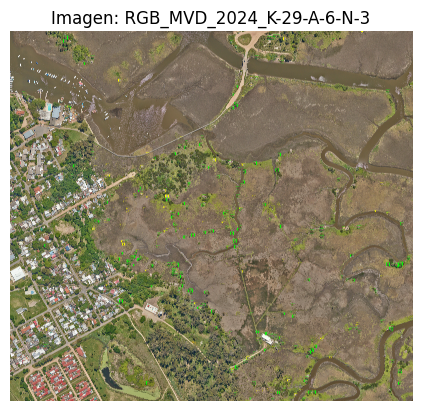

In [63]:
coco_annotations_path = DOWNLOAD_COCO_ANNOTATIONS_FOLDER / "coco_annotations.json"
VisualizadorCocoDataset.show_annotated_image_path(image_file_path, coco_annotations_path, image_name)

Mostramos los puntos:

In [64]:
predictions.as_pandas()

,x1,y1,x2,y2,confidence,class_id,class_name
0,2737.037628,253.719406,2912.327393,430.889221,0.762679,0,palmera-sana
1,2739.061150,253.918152,2912.669434,431.465332,0.888002,1,palmera-infectada
2,2710.959747,432.802521,2886.161194,594.555664,0.886643,1,palmera-infectada
3,13130.331177,283.335144,13270.345581,426.731873,0.956556,1,palmera-infectada
4,13251.988770,289.718109,13311.817871,431.168365,0.931218,1,palmera-infectada
...,...,...,...,...,...,...,...
439,14649.147659,18180.093597,14731.678131,18262.682587,0.847038,2,palmera-muerta
440,15335.093201,18246.791870,15468.648010,18374.453796,0.920590,0,palmera-sana
441,15293.321106,18211.471161,15360.318054,18302.920380,0.847514,2,palmera-muerta
442,14783.657959,18617.758148,14847.718018,18754.000000,0.934567,1,palmera-infectada


#### Generar KML

In [65]:
jgw_data = ProcesadorAnotacionesMongoDB.load_jgw_file_from_mongodb(image_name=image_name, should_download=True)
pprint(jgw_data)

2025-09-14 13:42:39.660 | SUCCESS  | modulo_apps.labeling.procesador_anotaciones_mongodb:load_jgw_file_from_mongodb:688 - Archivo JGW guardado en downloads\jgw\jgw_data.json.


{'x_origin': 559413.391802,
 'x_pixel_size': 0.05,
 'x_rotation': 0.0,
 'y_origin': 6150656.721772,
 'y_pixel_size': -0.05,
 'y_rotation': 0.0}


In [66]:
gdf = ProcesadorGeoJSONKML.create_geojson_from_annotations(image_name, coco_annotations, jgw_data, should_download=True)
gdf.head()

2025-09-14 13:42:40.346 | INFO     | modulo_apps.labeling.procesador_geojson_kml:create_geojson_from_annotations:297 - GeoJSON guardado en downloads\geojson\annotations.geojson


,name,annotation_id,confidence,bbox_x,bbox_y,bbox_width,bbox_height,global_tl_x,global_tl_y,global_br_x,global_br_y,geometry
0,palmera-sana,1,0.76,2737.037628,253.719406,175.289764,177.169815,559550.243683,6.150644e+06,559559.008172,6.150635e+06,POINT (-56.34906 -34.7847)
1,palmera-infectada,2,0.89,2739.061150,253.918152,173.608284,177.547180,559550.344859,6.150644e+06,559559.025274,6.150635e+06,POINT (-56.34906 -34.7847)
2,palmera-infectada,3,0.89,2710.959747,432.802521,175.201447,161.753143,559548.939789,6.150635e+06,559557.699862,6.150627e+06,POINT (-56.34908 -34.78478)
3,palmera-infectada,4,0.96,13130.331177,283.335144,140.014404,143.396729,560069.908361,6.150643e+06,560076.909081,6.150635e+06,POINT (-56.34339 -34.78467)
4,palmera-infectada,5,0.93,13251.988770,289.718109,59.829102,141.450256,560075.991240,6.150642e+06,560078.982696,6.150635e+06,POINT (-56.34335 -34.78468)


In [67]:
kml = ProcesadorGeoJSONKML.generate_kml_from_geojson(gdf, should_download=True)

2025-09-14 13:42:40.462 | INFO     | modulo_apps.labeling.procesador_geojson_kml:generate_kml_from_geojson:432 - Archivo KML guardado en downloads\kmls\palmeras.kml


In [68]:
# Test
kml_text = kml.to_string()
gdf_test = ProcesadorGeoJSONKML.convert_kml_to_geojson(kml_text)

2025-09-14 13:42:40.557 | SUCCESS  | modulo_apps.labeling.procesador_geojson_kml:convert_kml_to_geojson:120 - Conversión exitosa.
